In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from JacobianODE.jacobians.run_analytics import run_analytics
from JacobianODE.jacobians import load_run, create_dataloaders, load_checkpoint
import torch

# Analytics Report

In [7]:
WANDB_ENTITY = "JacobianODE"

WANDB_PROJECT = "Lorenz_INDall_N1_D1_NormTrue_T3__JacobianODE"
WANDB_GROUP = "spline_coupling__geometric_noise__sweep_lc_x_kl_dyn"

# WANDB_PROJECT = "Lorenz_INDall_N25_D1_NormTrue_T3__JacobianODE"
# WANDB_GROUP = "spline_coupling__geometric_noise__sweep_lc_x_kl_dyn"
# # WANDB_GROUP = "spline_coupling__geometric_noise__sweep_lc_x_kl_dyn_100step"

# WANDB_PROJECT = "Lorenz_PARTIAL_N25_D1_NormTrue_T3__JacobianODE"
# WANDB_GROUP = "spline_coupling__jacobian_noise__sweep_lc_x_kl_dyn_30step"

# WANDB_PROJECT = "Lorenz_IND0_N100_D1_NormTrue_T3__spline_coupling__JacobianODE"
# # WANDB_GROUP = "sweep_from_scratch_spline_coupling_lc_9vals__klNNone_1.0__klD0_0.0001_0.001_0.01_0.1_1__te0.0_enc_warmup_5_vaetrue" # 108 runs
# WANDB_GROUP = "sweep_from_scratch_spline_coupling_lc_9vals__klNnull__klD0_0.0001_0.001_0.01_0.1_1__te0.0_enc_warmup_5_vaetrue" # 54 runs (lc v kl_dyn_weight, pred_steps = 10)

# WANDB_PROJECT = "Lorenz_IND0_N100_D1_NormTrue_T7__spline_coupling__JacobianODE"
# WANDB_GROUP = None

# WANDB_PROJECT = "WMTask_INDall_N1_D1_NormTrue_T17__spline_coupling__JacobianODE"
# WANDB_GROUP = None

# WANDB_PROJECT = "WMTask_IND1926273140555669819498104_N10_D1_NormTrue_T10__spline_coupling__JacobianODE"
# WANDB_GROUP = None

# WANDB_PROJECT = "WMTask_INDall_N1_D1_NormTrue_T128__JacobianODE"
# # WANDB_GROUP = None
# # WANDB_GROUP = "spline_coupling__sweep_lc_x_kl_dyn_vae_sample_all_losses"
# # WANDB_GROUP = "mlp_diffeo__sweep_lc_x_kl_dyn_vae_sample_all_losses"
# WANDB_GROUP = "spline_coupling__geometric_noise__sweep_lc_x_kl_dyn"

SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs"
# TRUE_LYAPUNOV = [0.91, 0.0, -14.57]  # None for wmtask (overridden from config)
TRUE_LYAPUNOV = None

No run_id provided — selecting best run from group 'spline_coupling__geometric_noise__sweep_lc_x_kl_dyn' ...
Found 81 total runs in JacobianODE/Lorenz_INDall_N1_D1_NormTrue_T3__JacobianODE (group=spline_coupling__geometric_noise__sweep_lc_x_kl_dyn)
All runs (state, loop_closure_weight, tangent_entropy_weight, kl_dyn_weight):
  byg0vulm: state=crashed, lc=0.0, te=0.0, kl_dyn=1e-06
  jurujdv9: state=finished, lc=0.0, te=0.0, kl_dyn=0.0
  nzx5mjfu: state=finished, lc=0.0, te=0.0, kl_dyn=1e-05
  d98xnljb: state=finished, lc=0.0, te=0.0, kl_dyn=0.1
  o6pxwqye: state=finished, lc=0.0, te=0.0, kl_dyn=0.001
  6d32uvyg: state=finished, lc=0.0, te=0.0, kl_dyn=0.0001
  d6p9qow5: state=finished, lc=0.0, te=0.0, kl_dyn=0.01
  cmt3ldxu: state=finished, lc=0.0, te=0.0, kl_dyn=1.0
  3817w1ey: state=finished, lc=1e-06, te=0.0, kl_dyn=1e-06
  as1e8rjx: state=finished, lc=1e-06, te=0.0, kl_dyn=0.0
  6dky9clc: state=finished, lc=0.0, te=0.0, kl_dyn=10.0
  9lx4ju5h: state=finished, lc=1e-06, te=0.0, kl_dyn

Sequence Indices:   0%|          | 0/1155 [00:00<?, ?it/s]

Train dataset shape: torch.Size([25410, 45, 3])
Validation dataset shape: torch.Size([8085, 45, 3])
Test dataset shape: torch.Size([3465, 45, 3])
Train trajectories dataset shape: torch.Size([22, 1200, 3])
Validation trajectories dataset shape: torch.Size([7, 1200, 3])
Test trajectories dataset shape: torch.Size([3, 1200, 3])
Loading checkpoint epoch=56-step=11400.ckpt...


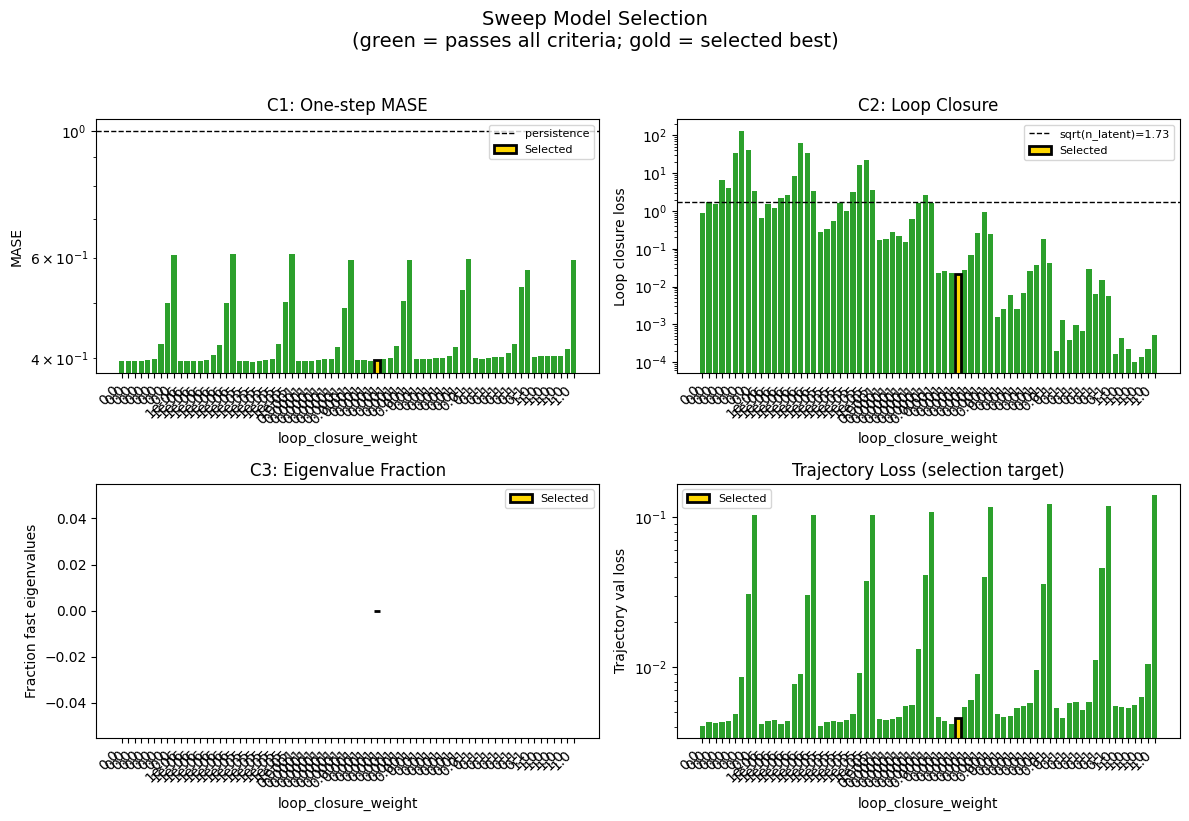

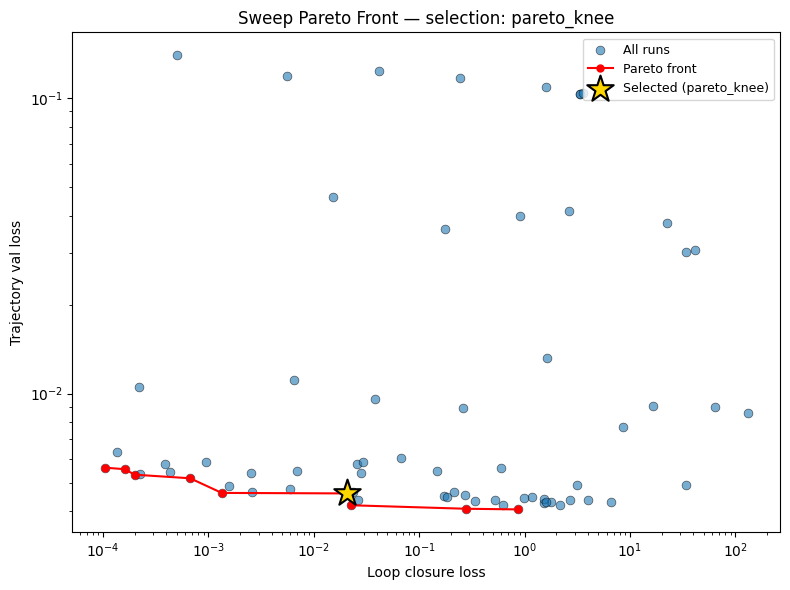

Computing reconstruction ...


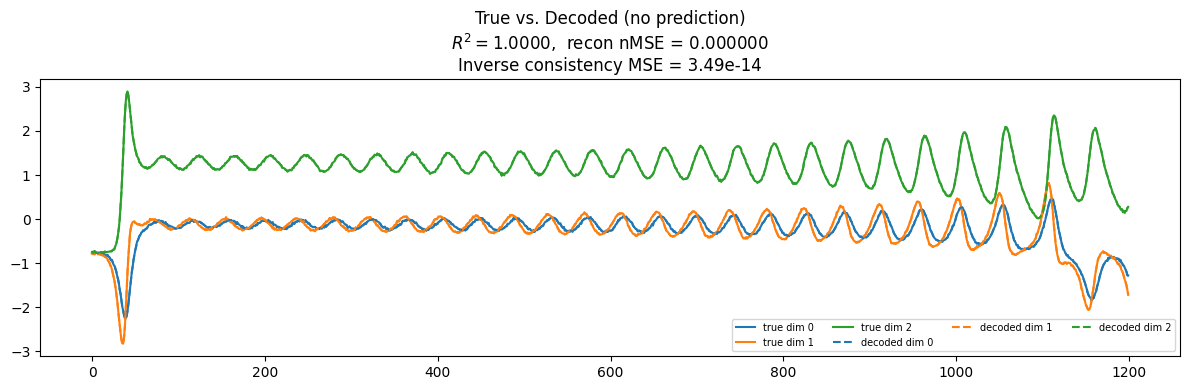

Computing MASE ...


MASE batches:   0%|          | 0/10 [00:00<?, ?it/s]

Teacher-forced MASE: 0.4070
Free-running MASE:   0.6297


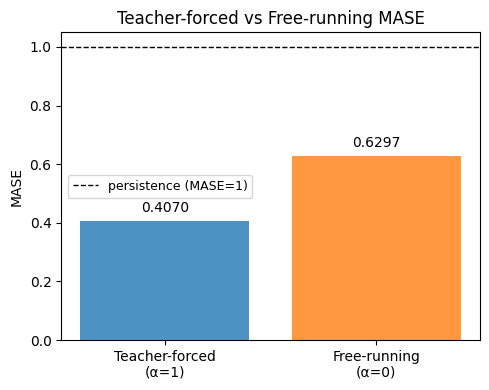

Computing latent utilization ...
Entropy-based utilization: 0.545


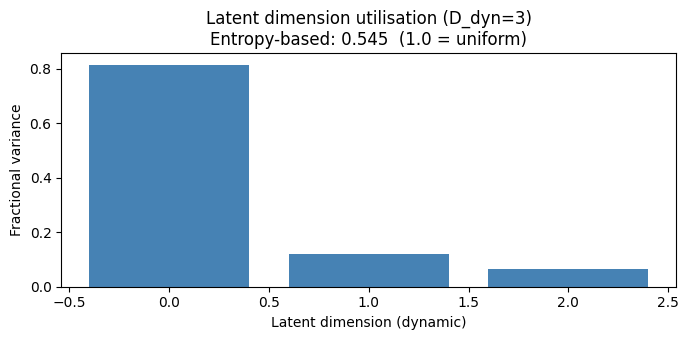

Computing Lyapunov exponents ...
  Computing full-trajectory Lyapunov (3 test trajs, T=1200) ...
    Traj 0: [  0.26801673   0.02691391 -15.4151945 ]
    Traj 1: [  0.35834184  -0.07773581 -15.436223  ]
    Traj 2: [  0.35662377  -0.03956537 -15.439656  ]
Predicted Lyapunov exponents (batch+burn-in, 128 windowed trajs):
  λ_1 = +0.6185 ± 0.2703
  λ_2 = -0.0626 ± 0.1021
  λ_3 = -15.1640 ± 0.4112
Predicted Lyapunov exponents (full-length, 3 test trajs):
  λ_1 = +0.3277 ± 0.0517
  λ_2 = -0.0301 ± 0.0530
  λ_3 = -15.4304 ± 0.0132
Empirical Lyapunov exponents (mean ± std):
  λ_1 = +0.3846 ± 0.0251
  λ_2 = -0.1716 ± 0.0444
  λ_3 = -13.8799 ± 0.0398


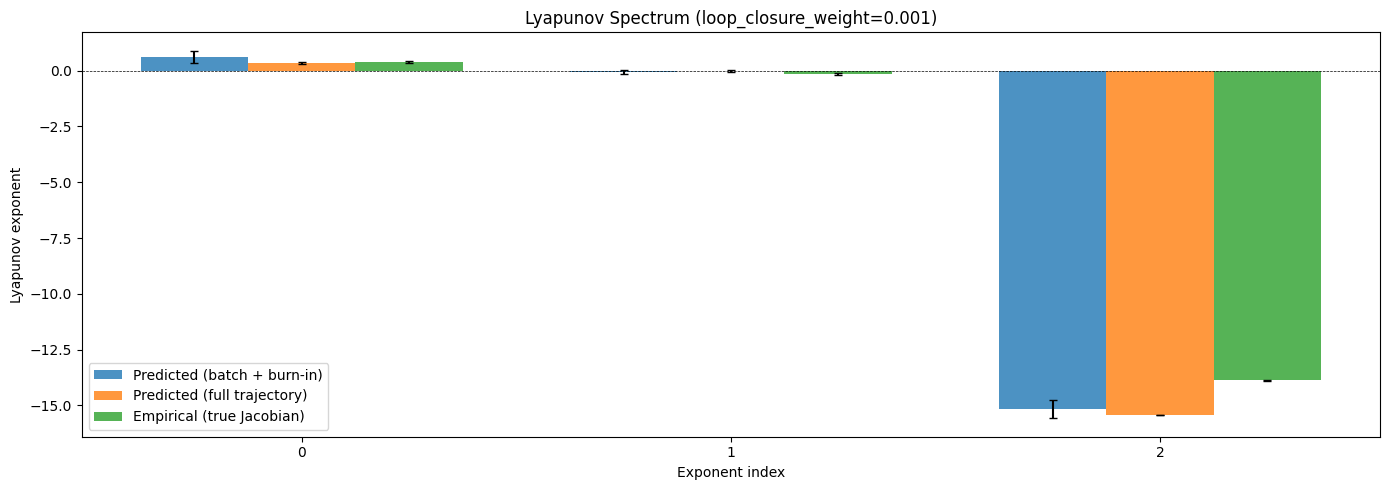

Mean KY dim (predicted): 2.019 ± 0.001
Mean KY dim (empirical): 2.015 ± 0.002


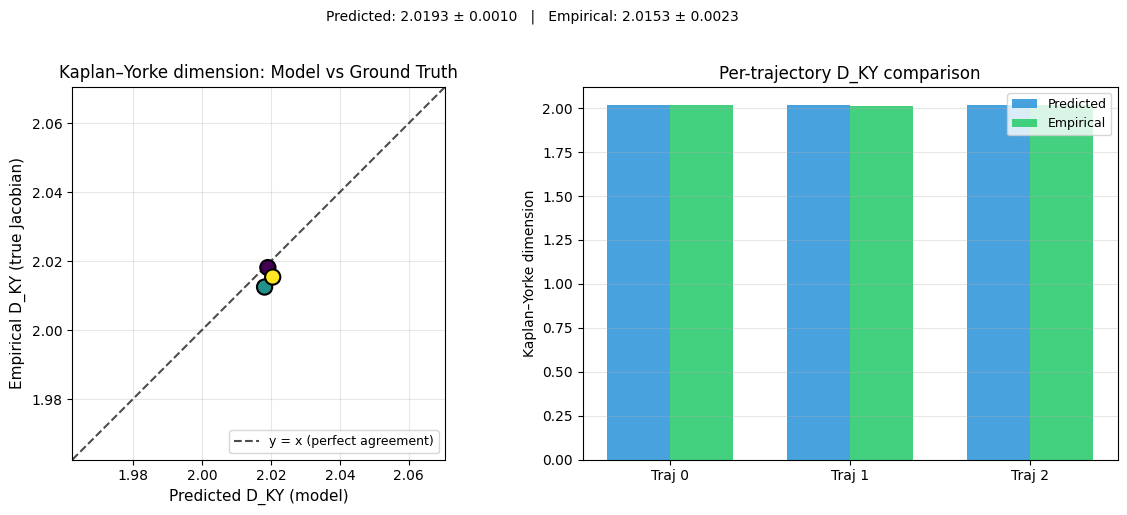

Mean KY dim (burn-in):   2.037 ± 0.015


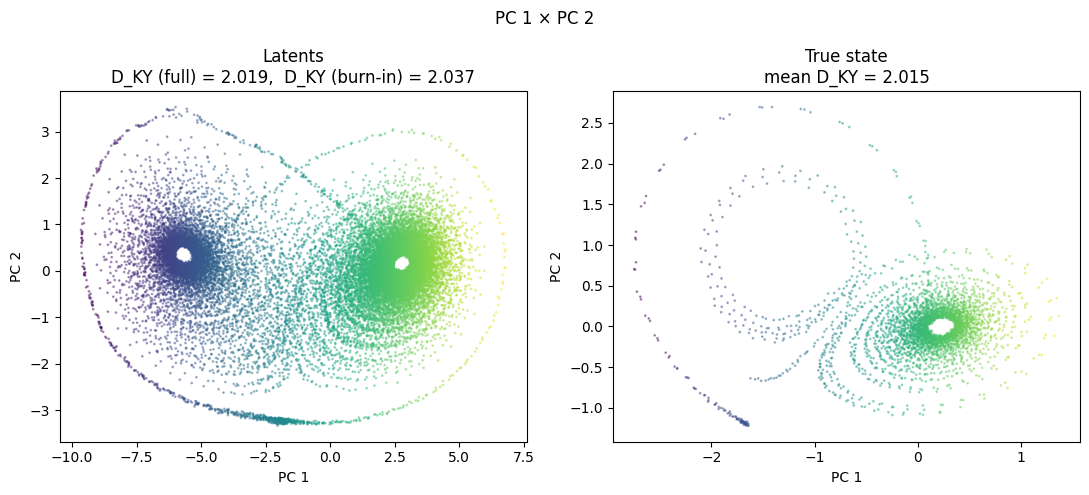

Computing prediction windows ...
Windows: 117 — nMSE min=0.0010, median=0.0029, mean=0.0082, max=0.2382


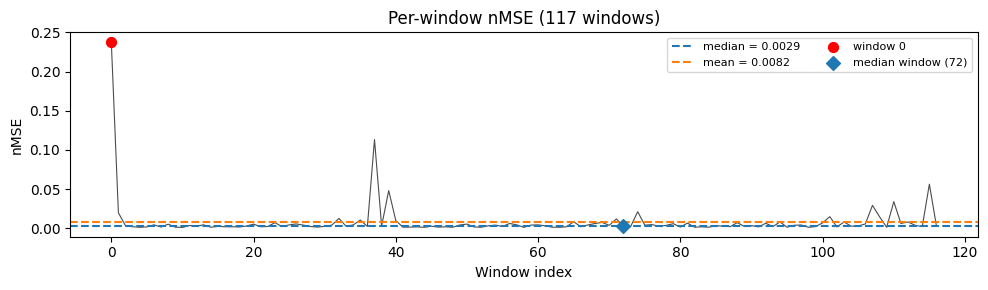

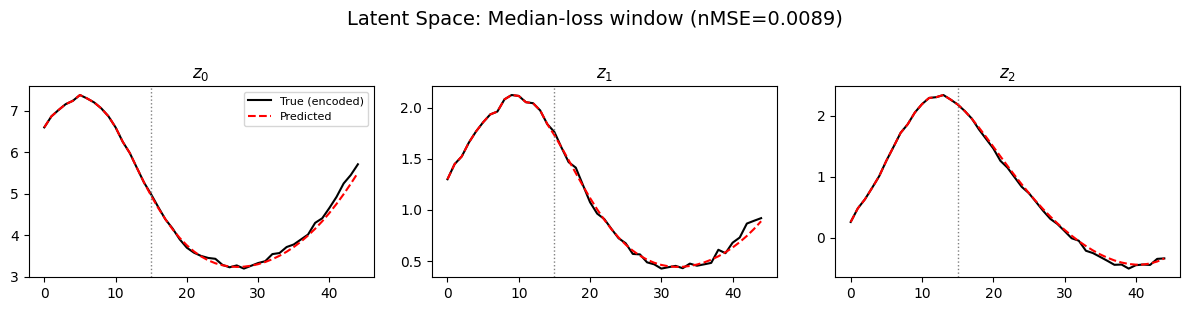

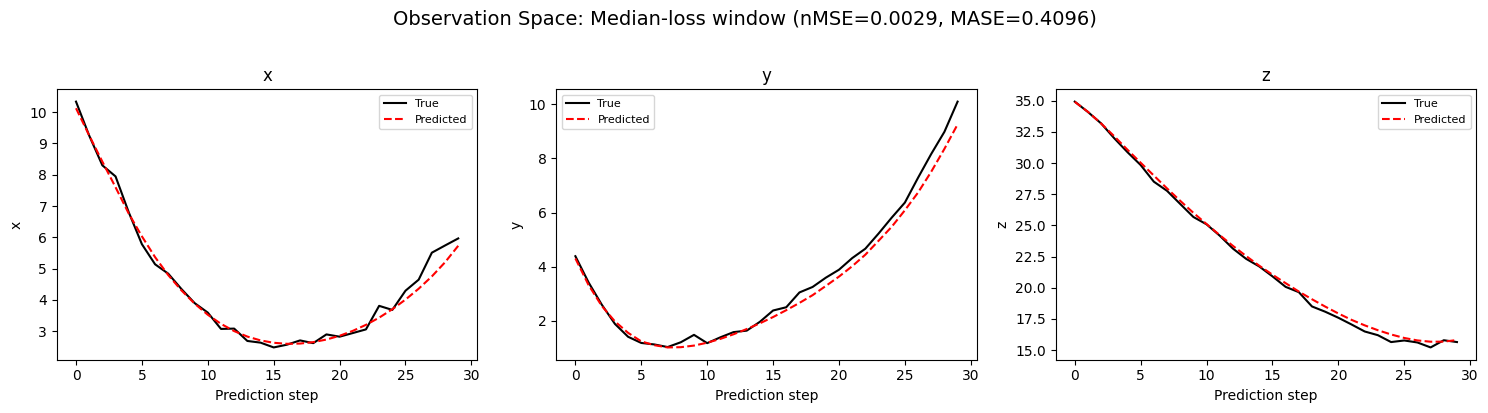

Computing long trajectory prediction ...


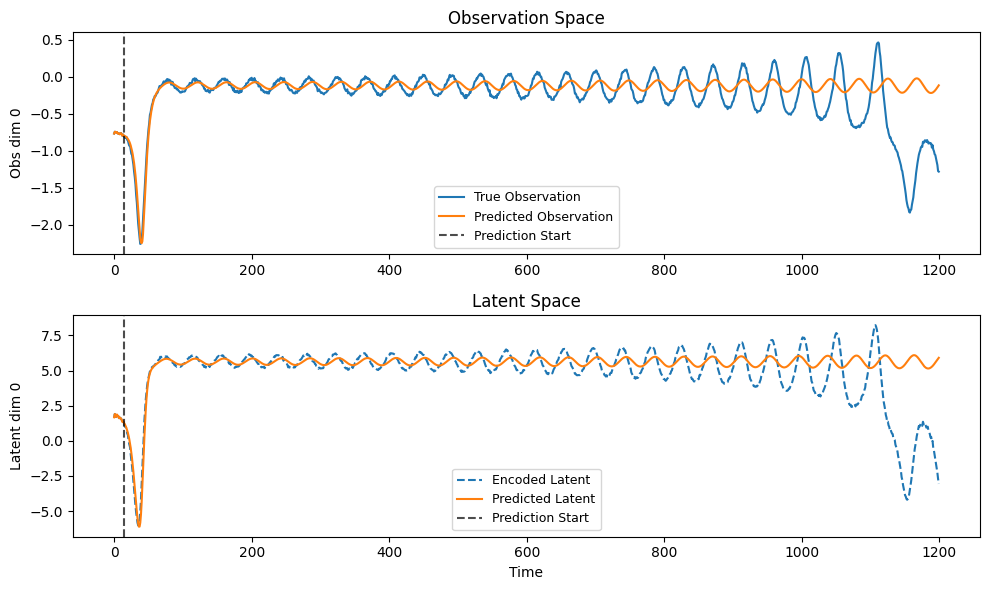

Computing encoder/decoder Jacobians ...
encoder_jacobian: (128, 3, 3)
decoder_jacobian: (128, 3, 3)


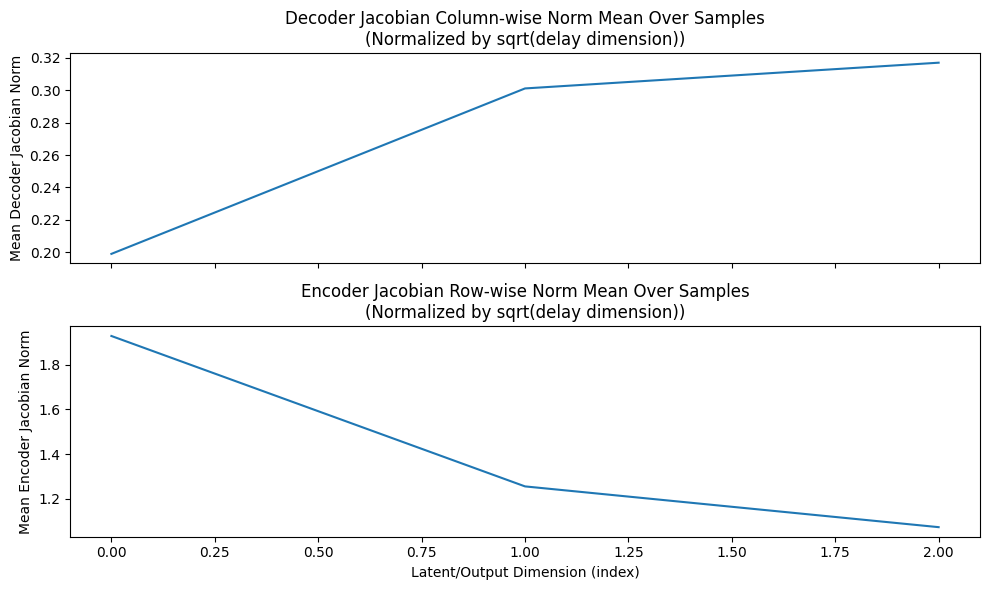

Computing amplification loss ...
Amplification loss — True state: 0.000186
Amplification loss — Latent:     0.000171


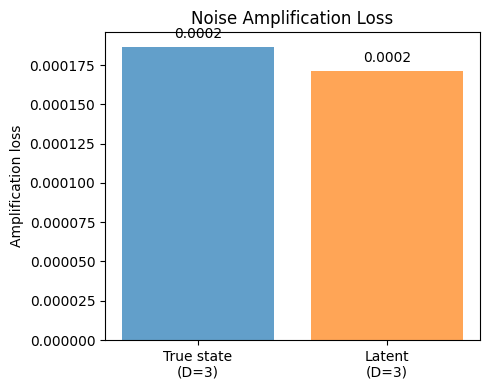

In [8]:
# Implementation is typed as dict | tuple | None; marimo/pyright need a runtime
# narrow before unpacking when return_model=True (always a 3-tuple then).
_analytics_out = run_analytics(
    wandb_entity=WANDB_ENTITY,
    wandb_project=WANDB_PROJECT,
    # run_id="4rl9mvew",
    # run_id="joede8bu",
    ranking_method='pareto_knee',
    # ranking_method='minimax_log_score',
    save_dir=SAVE_DIR,
    wandb_group=WANDB_GROUP,
    true_lyapunov=TRUE_LYAPUNOV,
    lyapunov_burn_in_steps=1000,
    lyapunov_burn_in_drop=200,
    # output='html',
    output='show',
    # output=[],
    # sections=[],             # skip ALL analytics
    output_dir='reports',
    return_model=True,
    # use_all_runs=True,
)
assert isinstance(_analytics_out, tuple) and len(_analytics_out) == 3
_result, lit_model, run_id = _analytics_out

# Geometric Noise Analysis

In [7]:

wandb_project_path = f"{WANDB_ENTITY}/{WANDB_PROJECT}"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load config + data (model weights already loaded by run_analytics)
_run, cfg, _eq, dt, values, _, _, _, _, _ = load_run(
    wandb_project_path, run_id=run_id, save_dir=SAVE_DIR,
    generate_data=True, verbose=True,
)
_train_dl, _val_dl, _test_dl, trajs = create_dataloaders(
    cfg, values, verbose=True, return_full_obs=True,
)

lit_model_analysis = lit_model.to(device)
lit_model_analysis.eval()

print(f"\nrun_id: {run_id}")
print(f"device: {device}")
print(f"data shape: {values.shape}")
print(f"n_latent: {lit_model_analysis.encoder.n_latent}")

Sequence Indices:   0%|          | 0/1131 [00:00<?, ?it/s]

Train dataset shape: torch.Size([24882, 45, 25])
Validation dataset shape: torch.Size([7917, 45, 25])
Test dataset shape: torch.Size([3393, 45, 25])
Train trajectories dataset shape: torch.Size([22, 1176, 25])
Validation trajectories dataset shape: torch.Size([7, 1176, 25])
Test trajectories dataset shape: torch.Size([3, 1176, 25])

run_id: joede8bu
device: cuda
data shape: (32, 1200, 3)
n_latent: 25


Test trajectories: torch.Size([3, 1176, 25])
Latent dynamic z:  torch.Size([3, 1176, 3])


/home/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



Geometric Noise Metric Analysis (G = J_f^T J_f)

Determinant of J_f (should be ±1):
  mean |det| = 1.000000,  std = 0.000000

Singular values of J_f (mean ± std across all points):
  σ_1 = 1.4399 ± 0.1370
  σ_2 = 1.1451 ± 0.0764
  σ_3 = 0.6132 ± 0.0574

Metric eigenvalues (G = J^T J):
  λ_1(G) = 0.3793 ± 0.0673
  λ_2(G) = 1.3171 ± 0.1719
  λ_3(G) = 2.0921 ± 0.4500

Condition number of G (max λ / min λ):
  mean = 5.9975,  std = 3.3895,  max = 27.3849

Frobenius distance from identity ||G - I||_F:
  mean = 1.3171,  std = 0.4245,  max = 3.7957

Log-Euclidean distance from identity ||log(G)||_F:
  mean = 1.2622,  std = 0.2491,  max = 2.3559


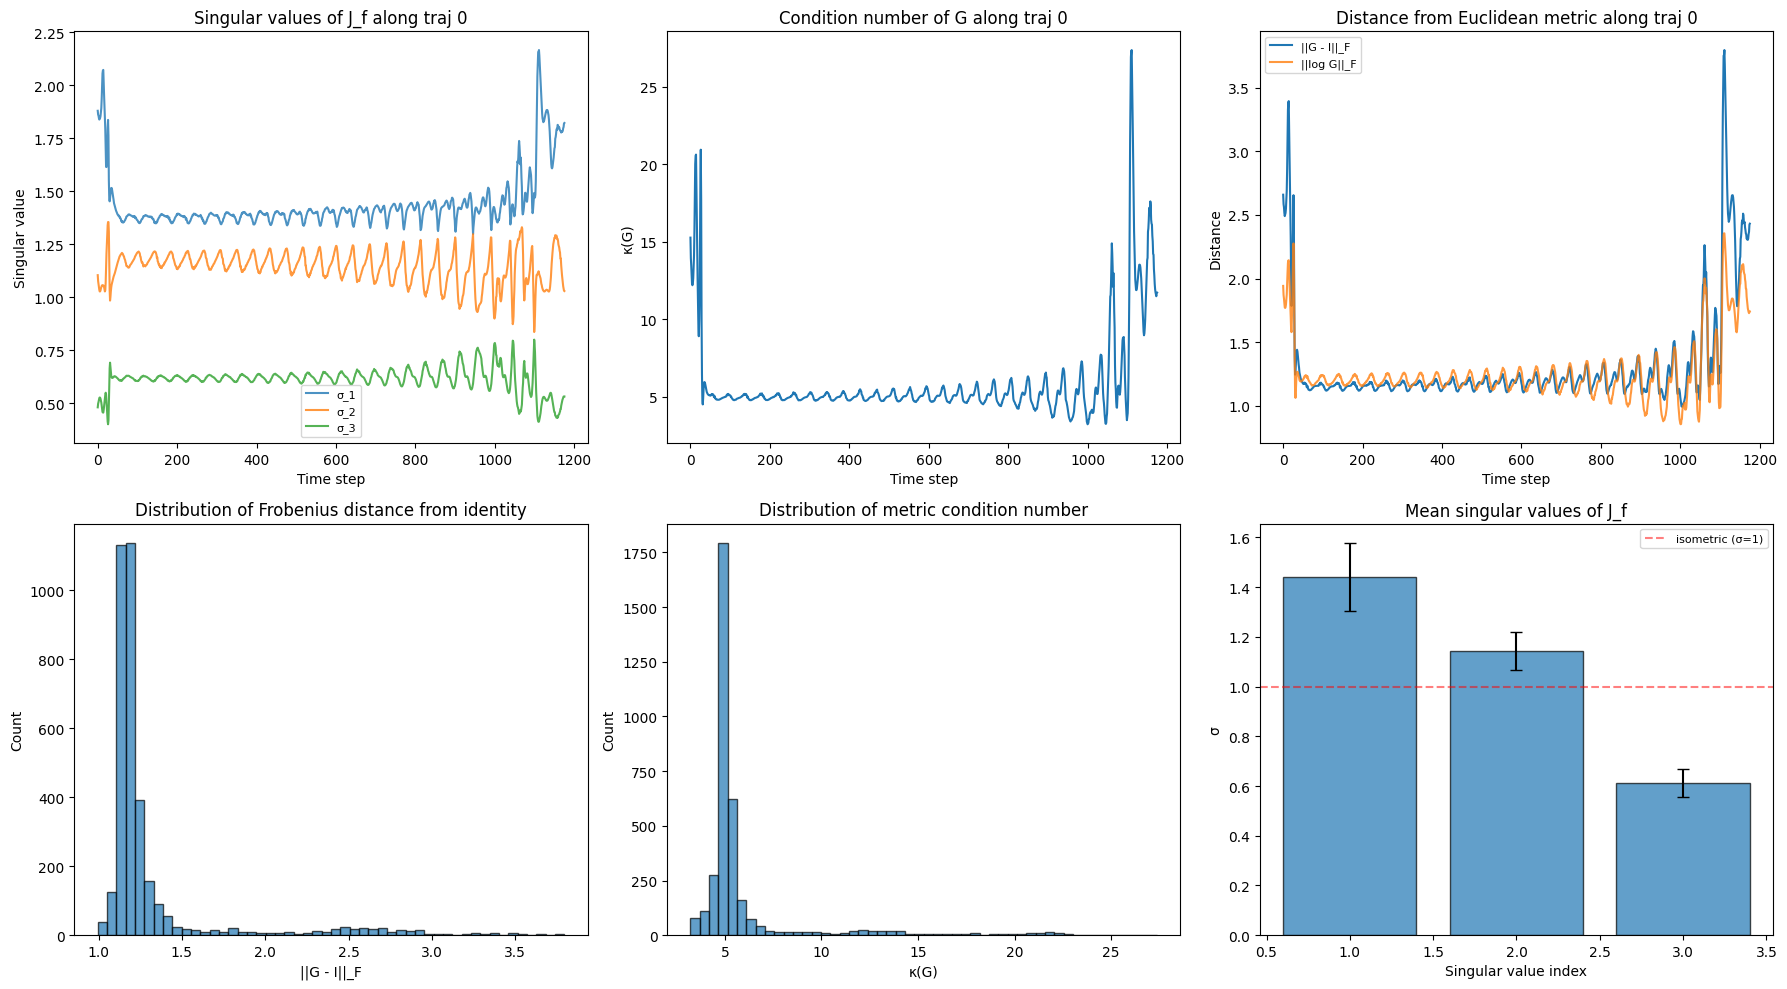

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from torch.func import jacrev, vmap

# --- Check that model has geometric noise ---
if not getattr(lit_model_analysis, "geometric_noise_enabled", False):
    print("⚠ This model does not have geometric noise enabled. Skipping.")
else:
    noise_warp = lit_model_analysis.noise_warp
    n_target_dims = lit_model_analysis.n_target_dims

    # --- Encode test trajectories ---
    with torch.no_grad():
        traj_seq = torch.as_tensor(trajs["test_trajs"].sequence).float().to(device)
        z_seq = lit_model_analysis.encode_trajectory(traj_seq)
        z_dyn = z_seq[..., :n_target_dims] if n_target_dims is not None else z_seq
    print(f"Test trajectories: {traj_seq.shape}")
    print(f"Latent dynamic z:  {z_dyn.shape}")

    N_traj, T, D = z_dyn.shape

    # --- Compute Jacobian of noise_warp at every point ---
    z_flat = z_dyn.reshape(-1, D)

    def f_single(x):
        return noise_warp(x.unsqueeze(0)).squeeze(0)

    # vmap over all points
    J_all = vmap(jacrev(f_single))(z_flat)  # (N*T, D, D)
    J_all = J_all.reshape(N_traj, T, D, D)

    # --- Metric tensor G = J^T J at each point ---
    G = torch.einsum("btij, btik -> btjk", J_all, J_all)  # (N, T, D, D)
    I_D = torch.eye(D, device=G.device, dtype=G.dtype)

    # --- Eigenvalues of G ---
    eigvals = torch.linalg.eigvalsh(G)  # (N, T, D), sorted ascending

    # --- Singular values of J ---
    svd_vals = torch.linalg.svdvals(J_all)  # (N, T, D)

    # --- Determinant (should be ±1 for volume-preserving flow) ---
    det_J = torch.linalg.det(J_all)

    # --- Distance from Euclidean: ||G - I||_F at each point ---
    G_minus_I = G - I_D
    frob_dist = torch.linalg.norm(G_minus_I.reshape(N_traj, T, D * D), dim=-1)  # (N, T)

    # --- Condition number: max eigval / min eigval ---
    cond_number = eigvals[..., -1] / eigvals[..., 0].clamp(min=1e-8)  # (N, T)

    # --- Log-Euclidean distance: ||log(G)||_F ---
    log_eigvals = torch.log(eigvals.clamp(min=1e-8))
    log_euclid_dist = torch.linalg.norm(log_eigvals, dim=-1)  # (N, T)

    # --- Print summary statistics ---
    print(f"\n{'='*60}")
    print(f"Geometric Noise Metric Analysis (G = J_f^T J_f)")
    print(f"{'='*60}")
    print(f"\nDeterminant of J_f (should be ±1):")
    print(f"  mean |det| = {det_J.abs().mean():.6f},  std = {det_J.abs().std():.6f}")

    print(f"\nSingular values of J_f (mean ± std across all points):")
    sv_flat = svd_vals.reshape(-1, D)
    for _i in range(D):
        print(f"  σ_{_i+1} = {sv_flat[:, _i].mean():.4f} ± {sv_flat[:, _i].std():.4f}")

    print(f"\nMetric eigenvalues (G = J^T J):")
    eig_flat = eigvals.reshape(-1, D)
    for _i in range(D):
        print(f"  λ_{_i+1}(G) = {eig_flat[:, _i].mean():.4f} ± {eig_flat[:, _i].std():.4f}")

    print(f"\nCondition number of G (max λ / min λ):")
    print(f"  mean = {cond_number.mean():.4f},  std = {cond_number.std():.4f},  max = {cond_number.max():.4f}")

    print(f"\nFrobenius distance from identity ||G - I||_F:")
    print(f"  mean = {frob_dist.mean():.4f},  std = {frob_dist.std():.4f},  max = {frob_dist.max():.4f}")

    print(f"\nLog-Euclidean distance from identity ||log(G)||_F:")
    print(f"  mean = {log_euclid_dist.mean():.4f},  std = {log_euclid_dist.std():.4f},  max = {log_euclid_dist.max():.4f}")

    # --- Plots ---
    _fig, _axes = plt.subplots(2, 3, figsize=(18, 10))

    # (0,0) Singular values along trajectory 0
    _ax = _axes[0, 0]
    for _i in range(D):
        _ax.plot(svd_vals[0, :, _i].detach().cpu().numpy(), label=f"σ_{_i+1}", alpha=0.8)
    _ax.set_xlabel("Time step")
    _ax.set_ylabel("Singular value")
    _ax.set_title("Singular values of J_f along traj 0")
    _ax.legend(fontsize=8)

    # (0,1) Condition number along trajectory 0
    _ax = _axes[0, 1]
    _ax.plot(cond_number[0].detach().cpu().numpy())
    _ax.set_xlabel("Time step")
    _ax.set_ylabel("κ(G)")
    _ax.set_title("Condition number of G along traj 0")

    # (0,2) Frobenius distance along trajectory 0
    _ax = _axes[0, 2]
    _ax.plot(frob_dist[0].detach().cpu().numpy(), label="||G - I||_F")
    _ax.plot(log_euclid_dist[0].detach().cpu().numpy(), label="||log G||_F", alpha=0.8)
    _ax.set_xlabel("Time step")
    _ax.set_ylabel("Distance")
    _ax.set_title("Distance from Euclidean metric along traj 0")
    _ax.legend(fontsize=8)

    # (1,0) Distribution of Frobenius distances (all points)
    _ax = _axes[1, 0]
    _ax.hist(frob_dist.detach().cpu().numpy().ravel(), bins=50, alpha=0.7, edgecolor="black")
    _ax.set_xlabel("||G - I||_F")
    _ax.set_ylabel("Count")
    _ax.set_title("Distribution of Frobenius distance from identity")

    # (1,1) Distribution of condition numbers (all points)
    _ax = _axes[1, 1]
    _ax.hist(cond_number.detach().cpu().numpy().ravel(), bins=50, alpha=0.7, edgecolor="black")
    _ax.set_xlabel("κ(G)")
    _ax.set_ylabel("Count")
    _ax.set_title("Distribution of metric condition number")

    # (1,2) Mean singular value bar chart
    _ax = _axes[1, 2]
    sv_mean = sv_flat.mean(0).detach().cpu().numpy()
    sv_std = sv_flat.std(0).detach().cpu().numpy()
    _ax.bar(range(1, D + 1), sv_mean, yerr=sv_std, capsize=4, edgecolor="black", alpha=0.7)
    _ax.axhline(y=1.0, color="r", linestyle="--", alpha=0.5, label="isometric (σ=1)")
    _ax.set_xlabel("Singular value index")
    _ax.set_ylabel("σ")
    _ax.set_title("Mean singular values of J_f")
    _ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# $G$-Orthogonal Lyapunov Spectrum

Compute the Lyapunov spectrum using QR decomposition in the isotropic noise space $\mathcal{U}$, where Euclidean orthogonality is geometrically valid. The noise-warping map $f$ (an additive coupling flow) provides the pushforward/pullback between latent space and $\mathcal{U}$-space.

**Algorithm (per time step):**
1. Propagate tangent vectors: $Z' = \exp(J_\theta(z_t)\,\Delta t)\,Z_t$
2. Push to $\mathcal{U}$-space: $U' = J_f(z_{t+1})\,Z'$
3. QR in $\mathcal{U}$-space: $U' = Q_u R$
4. Pull back: $Z_{t+1} = J_f(z_{t+1})^{-1}\,Q_u$
5. Accumulate: $\lambda_i \mathrel{+}= \ln R_{ii}$

Latent trajectories: torch.Size([3, 1176, 3])  (N_traj=3, T=1176, D=3)
dt = 0.015020517097581317



Lyapunov Spectrum Comparison  (1175 steps, dt=0.015020517097581317)

Exponent             G-Orthogonal     Standard (Euclidean)
--------------------------------------------------------
  λ_1          0.3803 ± 0.0484      0.3798 ± 0.0431  
  λ_2         -0.0100 ± 0.0460     -0.0239 ± 0.0437  
  λ_3         -9.0574 ± 0.0071     -9.0431 ± 0.0055  


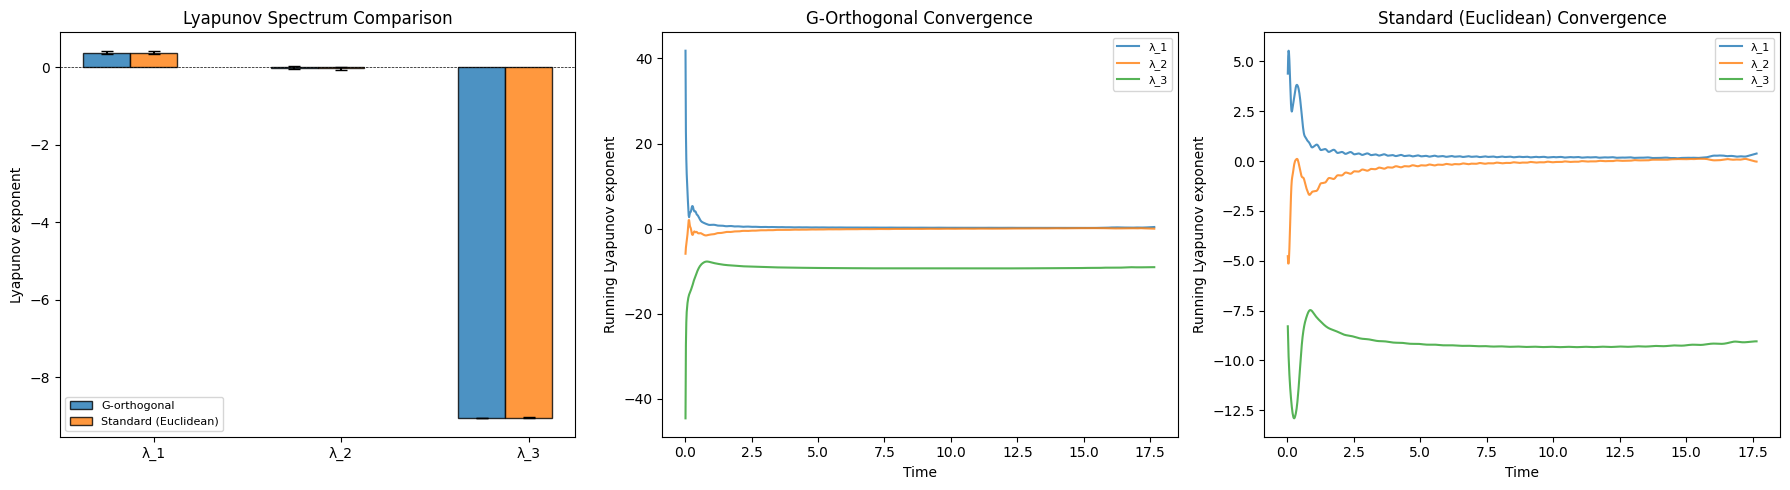

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from torch.func import jacrev, vmap

if not getattr(lit_model_analysis, "geometric_noise_enabled", False):
    print("⚠ This model does not have geometric noise enabled. Skipping.")
else:
    noise_warp = lit_model_analysis.noise_warp
    n_target_dims = lit_model_analysis.n_target_dims

    # --- Encode test trajectories ---
    with torch.no_grad():
        traj_seq = torch.as_tensor(trajs["test_trajs"].sequence).float().to(device)
        z_seq = lit_model_analysis.encode_trajectory(traj_seq)
        z_dyn = z_seq[..., :n_target_dims] if n_target_dims is not None else z_seq

    N_traj, T, D = z_dyn.shape
    print(f"Latent trajectories: {z_dyn.shape}  (N_traj={N_traj}, T={T}, D={D})")
    print(f"dt = {dt}")

    # --- Compute dynamics Jacobians J_theta(z_t) at every point ---
    with torch.no_grad():
        jacs = lit_model_analysis.compute_jacobians(z_dyn)  # (N, T, D, D)

    # --- Compute J_f (noise warp Jacobian) at every point via autodiff ---
    def _f_single(x):
        return noise_warp(x.unsqueeze(0)).squeeze(0)

    z_flat = z_dyn.reshape(-1, D)
    J_f_all = vmap(jacrev(_f_single))(z_flat)  # (N*T, D, D)
    J_f_all = J_f_all.reshape(N_traj, T, D, D)

    # =====================================================================
    # G-Orthogonal Lyapunov Exponents
    # =====================================================================
    # Iterate t = 0 .. T-2: use J_theta at z_t, J_f at z_{t+1}
    T_steps = T - 1

    Q_z = torch.eye(D, dtype=z_dyn.dtype, device=z_dyn.device).unsqueeze(0).expand(N_traj, -1, -1).clone()
    log_diag_sum_g = torch.zeros(N_traj, D, dtype=z_dyn.dtype, device=z_dyn.device)
    convergence_g = []  # running exponents at each step

    for t in range(T_steps):
        # Step 1: Forward propagation of tangent vectors
        M = torch.linalg.matrix_exp(jacs[:, t] * dt)          # (N, D, D)
        Z_prime = M @ Q_z                                      # (N, D, D)

        # Step 2: Pushforward to noise space U via J_f at z_{t+1}
        J_f_t1 = J_f_all[:, t + 1]                             # (N, D, D)
        U_prime = J_f_t1 @ Z_prime                              # (N, D, D)

        # Step 3: Standard QR in noise space
        Q_u, R = torch.linalg.qr(U_prime)
        diag_R = torch.diagonal(R, dim1=-2, dim2=-1)           # (N, D)
        signs = torch.sign(diag_R)
        signs[signs == 0] = 1.0
        Q_u = Q_u * signs.unsqueeze(-2)
        R = R * signs.unsqueeze(-1)

        # Step 4: Pullback to latent space — solve J_f @ Z = Q_u
        Q_z = torch.linalg.solve(J_f_t1, Q_u)                  # (N, D, D)

        # Step 5: Accumulate log stretching rates
        log_diag_sum_g += torch.log(torch.abs(torch.diagonal(R, dim1=-2, dim2=-1)))

        # Track convergence
        running_exp = log_diag_sum_g / ((t + 1) * dt)
        convergence_g.append(running_exp.mean(dim=0).detach().cpu().numpy().copy())

    lyap_g = (log_diag_sum_g / (T_steps * dt)).sort(descending=True, dim=-1).values  # (N, D)
    convergence_g = np.array(convergence_g)  # (T_steps, D)

    # =====================================================================
    # Standard (Euclidean) Lyapunov Exponents — same T_steps for comparison
    # =====================================================================
    Q_std = torch.eye(D, dtype=z_dyn.dtype, device=z_dyn.device).unsqueeze(0).expand(N_traj, -1, -1).clone()
    log_diag_sum_std = torch.zeros(N_traj, D, dtype=z_dyn.dtype, device=z_dyn.device)
    convergence_std = []

    for t in range(T_steps):
        M = torch.linalg.matrix_exp(jacs[:, t] * dt)
        Z_prime = M @ Q_std
        Q_std, R = torch.linalg.qr(Z_prime)
        diag_R = torch.diagonal(R, dim1=-2, dim2=-1)
        signs = torch.sign(diag_R)
        signs[signs == 0] = 1.0
        Q_std = Q_std * signs.unsqueeze(-2)
        R = R * signs.unsqueeze(-1)
        log_diag_sum_std += torch.log(torch.abs(torch.diagonal(R, dim1=-2, dim2=-1)))

        running_exp = log_diag_sum_std / ((t + 1) * dt)
        convergence_std.append(running_exp.mean(dim=0).detach().cpu().numpy().copy())

    lyap_std = (log_diag_sum_std / (T_steps * dt)).sort(descending=True, dim=-1).values
    convergence_std = np.array(convergence_std)

    # =====================================================================
    # Print results
    # =====================================================================
    lyap_g_mean = lyap_g.mean(dim=0).detach().cpu().numpy()
    lyap_g_std = lyap_g.std(dim=0).detach().cpu().numpy()
    lyap_std_mean = lyap_std.mean(dim=0).detach().cpu().numpy()
    lyap_std_std = lyap_std.std(dim=0).detach().cpu().numpy()

    print(f"\n{'='*60}")
    print(f"Lyapunov Spectrum Comparison  ({T_steps} steps, dt={dt})")
    print(f"{'='*60}")
    print(f"\n{'Exponent':<12} {'G-Orthogonal':>20} {'Standard (Euclidean)':>24}")
    print(f"{'-'*56}")
    for i in range(D):
        print(f"  λ_{i+1:<6}   {lyap_g_mean[i]:>8.4f} ± {lyap_g_std[i]:<8.4f}  {lyap_std_mean[i]:>8.4f} ± {lyap_std_std[i]:<8.4f}")

    if TRUE_LYAPUNOV is not None:
        true_le = np.sort(TRUE_LYAPUNOV)[::-1]
        print(f"\n  True:     {true_le}")

    # =====================================================================
    # Plots
    # =====================================================================
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # (0) Bar chart: G-orthogonal vs Standard vs True
    ax = axes[0]
    x_pos = np.arange(D)
    w = 0.25
    ax.bar(x_pos - w, lyap_g_mean, w, yerr=lyap_g_std, capsize=4,
           label="G-orthogonal", alpha=0.8, edgecolor="black")
    ax.bar(x_pos, lyap_std_mean, w, yerr=lyap_std_std, capsize=4,
           label="Standard (Euclidean)", alpha=0.8, edgecolor="black")
    if TRUE_LYAPUNOV is not None:
        true_le = np.sort(TRUE_LYAPUNOV)[::-1]
        ax.bar(x_pos + w, true_le, w, label="True", alpha=0.8, edgecolor="black")
    ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"λ_{i+1}" for i in range(D)])
    ax.set_ylabel("Lyapunov exponent")
    ax.set_title("Lyapunov Spectrum Comparison")
    ax.legend(fontsize=8)

    # (1) Convergence: G-orthogonal
    ax = axes[1]
    time_axis = np.arange(1, T_steps + 1) * dt
    # Sort columns descending by final value for consistent coloring
    sort_idx_g = np.argsort(convergence_g[-1])[::-1]
    for rank, i in enumerate(sort_idx_g):
        ax.plot(time_axis, convergence_g[:, i], label=f"λ_{rank+1}", alpha=0.8)
    if TRUE_LYAPUNOV is not None:
        for val in true_le:
            ax.axhline(val, color="k", linewidth=0.5, linestyle="--", alpha=0.5)
    ax.set_xlabel("Time")
    ax.set_ylabel("Running Lyapunov exponent")
    ax.set_title("G-Orthogonal Convergence")
    ax.legend(fontsize=8)

    # (2) Convergence: Standard
    ax = axes[2]
    sort_idx_std = np.argsort(convergence_std[-1])[::-1]
    for rank, i in enumerate(sort_idx_std):
        ax.plot(time_axis, convergence_std[:, i], label=f"λ_{rank+1}", alpha=0.8)
    if TRUE_LYAPUNOV is not None:
        for val in true_le:
            ax.axhline(val, color="k", linewidth=0.5, linestyle="--", alpha=0.5)
    ax.set_xlabel("Time")
    ax.set_ylabel("Running Lyapunov exponent")
    ax.set_title("Standard (Euclidean) Convergence")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# Noise Survival Analysis

Measure how the learned dynamics amplify or contract noise perturbations. For each latent point $z_t$, sample a noise perturbation $\delta z$, propagate it one step via $\delta z' = e^{J_\theta \Delta t}\,\delta z$, and compute the survival ratio $\|\delta z'\|^2 / \|\delta z\|^2$.

Two noise models are compared:
- **Geometric noise**: perturbation sampled in $\mathcal{U}$-space and pulled back through $f^{-1}$, so $\delta z$ is shaped by the learned metric.
- **Isotropic noise**: perturbation sampled directly in $z$-space (ignoring the noise warp).

Learned noise std in U-space (mean per dim): [0.00156122 0.00142603 0.00116024]
Isotropic noise std (geometric mean of learned std): 0.001335
Propagation steps: 10  (0.1502 time units)
Smallest singular value of propagator (mean): 0.172706

Noise Survival Analysis  (N_samples=32, steps=10)

Metric                          Geometric    Isotropic   Stable dir
----------------------------------------------------------------
  Mean ratio                       1.0006       1.5654       0.0289
  Median ratio                     0.8880       1.4061       0.0266
  Std ratio                        0.4626       0.7118       0.0095
  Frac > 1 (amplified)             0.3062       0.9826       0.0000
  Max ratio                        5.3590      10.4369       0.0916


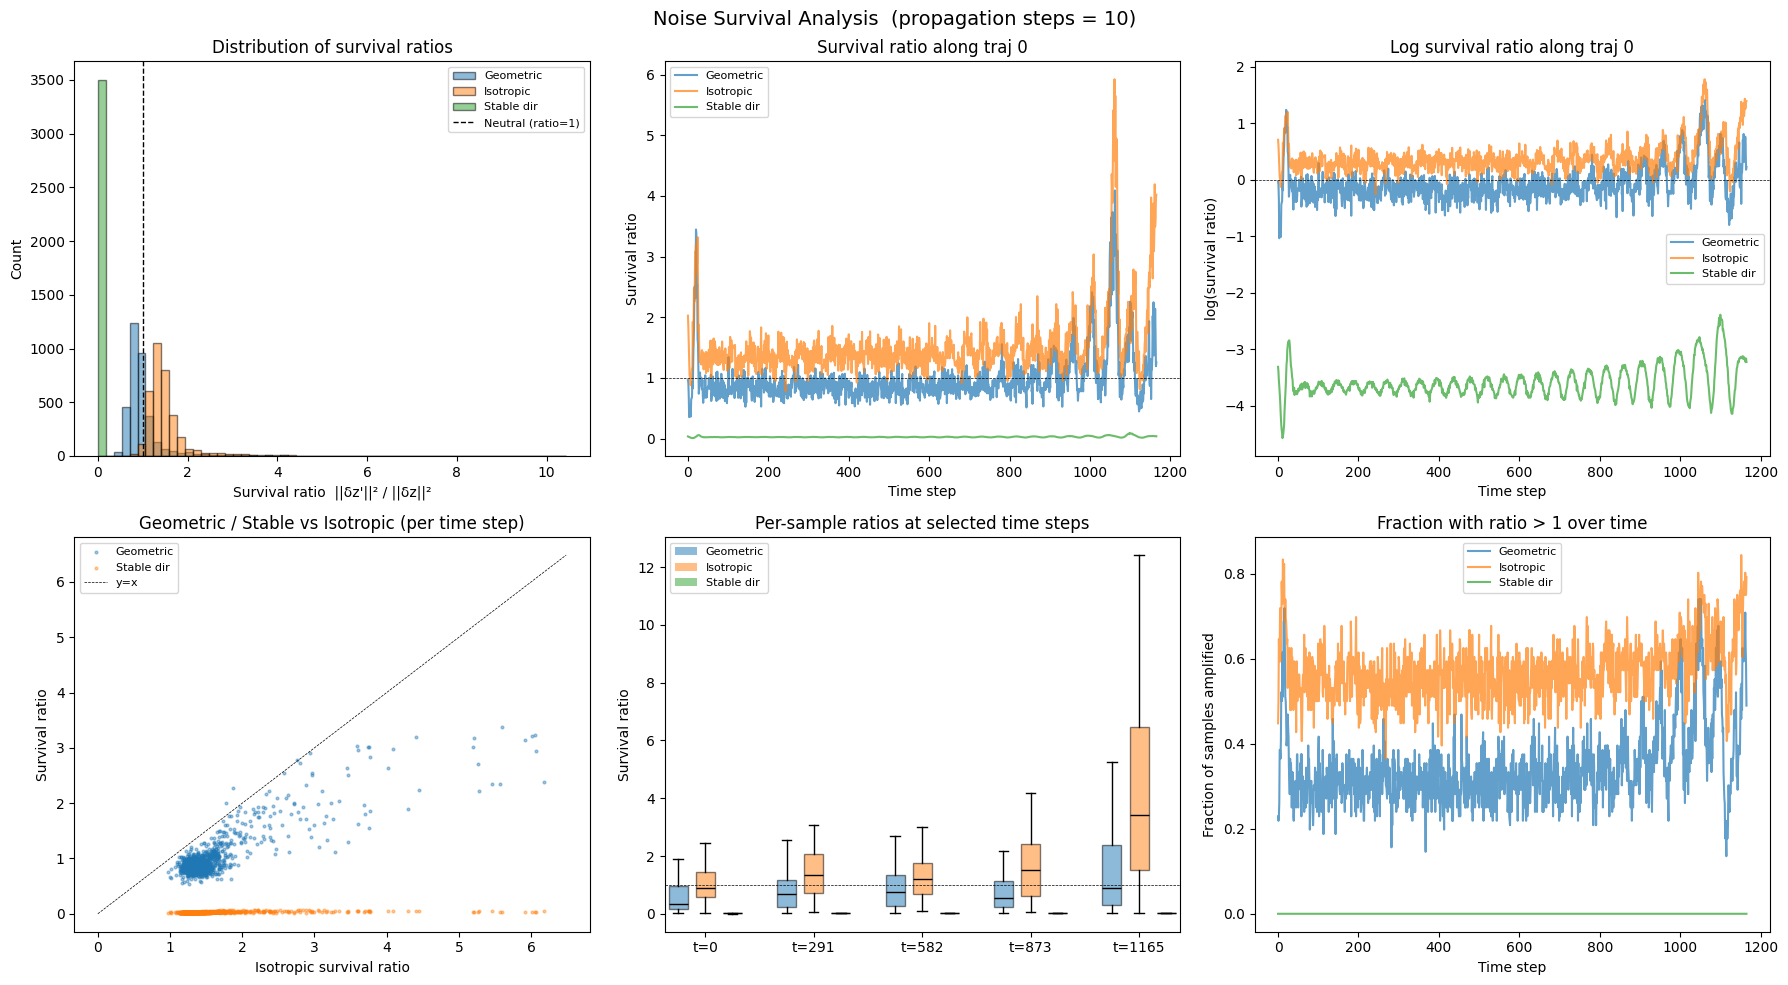

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from torch.func import jacrev, vmap

if not getattr(lit_model_analysis, "geometric_noise_enabled", False):
    print("⚠ This model does not have geometric noise enabled. Skipping.")
else:
    noise_warp = lit_model_analysis.noise_warp
    n_target_dims = lit_model_analysis.n_target_dims
    EPS = 1e-8
    N_NOISE_SAMPLES = 32  # noise samples per latent point
    PROPAGATION_STEPS = 10 # how many dynamics steps to propagate the perturbation

    # --- Encode test trajectories ---
    with torch.no_grad():
        traj_seq = torch.as_tensor(trajs["test_trajs"].sequence).float().to(device)
        z_seq = lit_model_analysis.encode_trajectory(traj_seq)
        z_dyn = z_seq[..., :n_target_dims] if n_target_dims is not None else z_seq

    N_traj, T, D = z_dyn.shape
    T_valid = T - PROPAGATION_STEPS  # starting points that have enough future steps
    assert T_valid > 0, f"PROPAGATION_STEPS={PROPAGATION_STEPS} >= T={T}"

    # --- Dynamics Jacobians ---
    with torch.no_grad():
        jacs = lit_model_analysis.compute_jacobians(z_dyn)  # (N, T, D, D)

    # --- Single-step propagators M_t = exp(J_theta * dt) at each point ---
    M_all = torch.linalg.matrix_exp(jacs * dt)  # (N, T, D, D)

    # --- Compose multi-step propagator: M_total[t] = M[t+n-1] @ ... @ M[t] ---
    M_total = M_all[:, :T_valid].clone()  # init with M[t] for step 0->1
    for k in range(1, PROPAGATION_STEPS):
        M_total = M_all[:, k:T_valid + k] @ M_total         # (N, T_valid, D, D)

    # --- Map all latent points to U-space and get learned noise std ---
    z_flat = z_dyn.reshape(-1, D)
    with torch.no_grad():
        u_flat = noise_warp(z_flat)                              # (N*T, D)
        log_var = lit_model_analysis.log_var_proj(u_flat)        # (N*T, D)
        std_u = torch.exp(0.5 * log_var)                        # learned per-point, per-dim std
    u_all = u_flat.reshape(N_traj, T, D)
    std_u_all = std_u.reshape(N_traj, T, D)

    print(f"Learned noise std in U-space (mean per dim): "
          f"{std_u_all.mean(dim=(0,1)).detach().cpu().numpy()}")

    # Geometric mean of learned std (scalar) for isotropic baseline
    # geometric mean = exp(mean(log(std))) = exp(0.5 * mean(log_var))
    iso_noise_std = torch.exp(0.5 * log_var.mean()).item()
    print(f"Isotropic noise std (geometric mean of learned std): {iso_noise_std:.6f}")
    print(f"Propagation steps: {PROPAGATION_STEPS}  ({PROPAGATION_STEPS * dt:.4f} time units)")

    # =====================================================================
    # Geometric noise: sample in U-space with learned std, pull back via f^{-1}
    # =====================================================================
    torch.manual_seed(0)
    eps_u = torch.randn(N_traj, T_valid, N_NOISE_SAMPLES, D, device=device)
    eps_u = eps_u * std_u_all[:, :T_valid].unsqueeze(2)

    u_expanded = u_all[:, :T_valid].unsqueeze(2).expand_as(eps_u)
    u_noisy = u_expanded + eps_u

    with torch.no_grad():
        z_noisy_geo = noise_warp.inverse(
            u_noisy.reshape(-1, D)
        ).reshape(N_traj, T_valid, N_NOISE_SAMPLES, D)

    dz_geo = z_noisy_geo - z_dyn[:, :T_valid].unsqueeze(2)
    dz_geo_prop = torch.einsum("ntij, ntsj -> ntsi", M_total, dz_geo)
    ratio_geo = (dz_geo_prop ** 2).sum(dim=-1) / ((dz_geo ** 2).sum(dim=-1) + EPS)

    # =====================================================================
    # Isotropic noise: sample directly in z-space
    # =====================================================================
    torch.manual_seed(0)
    eps_z = torch.randn(N_traj, T_valid, N_NOISE_SAMPLES, D, device=device) * iso_noise_std
    dz_iso = eps_z

    dz_iso_prop = torch.einsum("ntij, ntsj -> ntsi", M_total, dz_iso)
    ratio_iso = (dz_iso_prop ** 2).sum(dim=-1) / ((dz_iso ** 2).sum(dim=-1) + EPS)

    # =====================================================================
    # Most-stable direction noise: SVD of propagator, perturb along last
    # right singular vector (smallest singular value = most contracting)
    # =====================================================================
    # SVD of M_total: M = U @ diag(S) @ V^T — last col of V is most stable
    U_svd, S_svd, Vh_svd = torch.linalg.svd(M_total)  # Vh: (N, T_valid, D, D)
    v_stable = Vh_svd[:, :, -1, :]                     # (N, T_valid, D) — most stable direction

    # Match magnitude to geometric noise: scale so ||dz|| = geometric mean of learned std * sqrt(D)
    # (isotropic noise of std σ in D dims has expected norm σ*sqrt(D))
    target_norm = iso_noise_std * (D ** 0.5)

    torch.manual_seed(0)
    # Random sign & magnitude along the stable direction
    scalar = torch.randn(N_traj, T_valid, N_NOISE_SAMPLES, 1, device=device) * target_norm
    dz_stable = scalar * v_stable.unsqueeze(2)          # (N, T_valid, n_samples, D)

    dz_stable_prop = torch.einsum("ntij, ntsj -> ntsi", M_total, dz_stable)
    ratio_stable = (dz_stable_prop ** 2).sum(dim=-1) / ((dz_stable ** 2).sum(dim=-1) + EPS)

    print(f"Smallest singular value of propagator (mean): "
          f"{S_svd[:, :, -1].mean().item():.6f}")

    # =====================================================================
    # Statistics (average over noise samples)
    # =====================================================================
    mean_ratio_geo = ratio_geo.mean(dim=2)
    mean_ratio_iso = ratio_iso.mean(dim=2)
    mean_ratio_stable = ratio_stable.mean(dim=2)

    geo_np = mean_ratio_geo.detach().cpu().numpy()
    iso_np = mean_ratio_iso.detach().cpu().numpy()
    stb_np = mean_ratio_stable.detach().cpu().numpy()

    print(f"\n{'='*60}")
    print(f"Noise Survival Analysis  (N_samples={N_NOISE_SAMPLES}, "
          f"steps={PROPAGATION_STEPS})")
    print(f"{'='*60}")
    print(f"\n{'Metric':<28} {'Geometric':>12} {'Isotropic':>12} {'Stable dir':>12}")
    print(f"{'-'*64}")
    print(f"  {'Mean ratio':<26} {geo_np.mean():>12.4f} {iso_np.mean():>12.4f} {stb_np.mean():>12.4f}")
    print(f"  {'Median ratio':<26} {np.median(geo_np):>12.4f} {np.median(iso_np):>12.4f} {np.median(stb_np):>12.4f}")
    print(f"  {'Std ratio':<26} {geo_np.std():>12.4f} {iso_np.std():>12.4f} {stb_np.std():>12.4f}")
    print(f"  {'Frac > 1 (amplified)':<26} {(geo_np > 1).mean():>12.4f} {(iso_np > 1).mean():>12.4f} {(stb_np > 1).mean():>12.4f}")
    print(f"  {'Max ratio':<26} {geo_np.max():>12.4f} {iso_np.max():>12.4f} {stb_np.max():>12.4f}")

    # =====================================================================
    # Plots
    # =====================================================================
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Noise Survival Analysis  (propagation steps = {PROPAGATION_STEPS})",
                 fontsize=14)

    # (0,0) Distribution of mean survival ratios
    ax = axes[0, 0]
    all_max = max(geo_np.max(), iso_np.max(), stb_np.max(), 2.0)
    bins = np.linspace(0, all_max, 60)
    ax.hist(geo_np.ravel(), bins=bins, alpha=0.5, label="Geometric", edgecolor="black")
    ax.hist(iso_np.ravel(), bins=bins, alpha=0.5, label="Isotropic", edgecolor="black")
    ax.hist(stb_np.ravel(), bins=bins, alpha=0.5, label="Stable dir", edgecolor="black")
    ax.axvline(1.0, color="k", linestyle="--", linewidth=1, label="Neutral (ratio=1)")
    ax.set_xlabel("Survival ratio  ||δz'||² / ||δz||²")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of survival ratios")
    ax.legend(fontsize=8)

    # (0,1) Survival ratio along trajectory 0
    ax = axes[0, 1]
    ax.plot(geo_np[0], alpha=0.7, label="Geometric")
    ax.plot(iso_np[0], alpha=0.7, label="Isotropic")
    ax.plot(stb_np[0], alpha=0.7, label="Stable dir")
    ax.axhline(1.0, color="k", linestyle="--", linewidth=0.5)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Survival ratio")
    ax.set_title("Survival ratio along traj 0")
    ax.legend(fontsize=8)

    # (0,2) Log survival ratio along trajectory 0
    ax = axes[0, 2]
    ax.plot(np.log(geo_np[0] + EPS), alpha=0.7, label="Geometric")
    ax.plot(np.log(iso_np[0] + EPS), alpha=0.7, label="Isotropic")
    ax.plot(np.log(stb_np[0] + EPS), alpha=0.7, label="Stable dir")
    ax.axhline(0.0, color="k", linestyle="--", linewidth=0.5)
    ax.set_xlabel("Time step")
    ax.set_ylabel("log(survival ratio)")
    ax.set_title("Log survival ratio along traj 0")
    ax.legend(fontsize=8)

    # (1,0) Geometric vs Isotropic scatter (per time point, traj-averaged)
    ax = axes[1, 0]
    ax.scatter(iso_np.mean(axis=0), geo_np.mean(axis=0), s=4, alpha=0.4, label="Geometric")
    ax.scatter(iso_np.mean(axis=0), stb_np.mean(axis=0), s=4, alpha=0.4, label="Stable dir")
    lims = [0, max(iso_np.mean(axis=0).max(), geo_np.mean(axis=0).max(),
                   stb_np.mean(axis=0).max()) * 1.05]
    ax.plot(lims, lims, "k--", linewidth=0.5, label="y=x")
    ax.set_xlabel("Isotropic survival ratio")
    ax.set_ylabel("Survival ratio")
    ax.set_title("Geometric / Stable vs Isotropic (per time step)")
    ax.legend(fontsize=8)

    # (1,1) Per-sample ratio distribution at a few time steps
    ax = axes[1, 1]
    t_samples = np.linspace(0, T_valid - 1, 5, dtype=int)
    for idx, t_idx in enumerate(t_samples):
        data_geo = ratio_geo[:, t_idx, :].detach().cpu().numpy().ravel()
        data_iso = ratio_iso[:, t_idx, :].detach().cpu().numpy().ravel()
        data_stb = ratio_stable[:, t_idx, :].detach().cpu().numpy().ravel()
        ax.boxplot(data_geo, positions=[idx * 4], widths=0.7, patch_artist=True,
                   boxprops=dict(facecolor="tab:blue", alpha=0.5),
                   medianprops=dict(color="black"), showfliers=False)
        ax.boxplot(data_iso, positions=[idx * 4 + 1], widths=0.7, patch_artist=True,
                   boxprops=dict(facecolor="tab:orange", alpha=0.5),
                   medianprops=dict(color="black"), showfliers=False)
        ax.boxplot(data_stb, positions=[idx * 4 + 2], widths=0.7, patch_artist=True,
                   boxprops=dict(facecolor="tab:green", alpha=0.5),
                   medianprops=dict(color="black"), showfliers=False)
    ax.set_xticks([idx * 4 + 1 for idx in range(len(t_samples))])
    ax.set_xticklabels([f"t={t}" for t in t_samples])
    ax.axhline(1.0, color="k", linestyle="--", linewidth=0.5)
    ax.set_ylabel("Survival ratio")
    ax.set_title("Per-sample ratios at selected time steps")
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor="tab:blue", alpha=0.5, label="Geometric"),
                       Patch(facecolor="tab:orange", alpha=0.5, label="Isotropic"),
                       Patch(facecolor="tab:green", alpha=0.5, label="Stable dir")], fontsize=8)

    # (1,2) Fraction of amplified samples over time
    ax = axes[1, 2]
    frac_amp_geo = (ratio_geo > 1).float().mean(dim=(0, 2)).detach().cpu().numpy()
    frac_amp_iso = (ratio_iso > 1).float().mean(dim=(0, 2)).detach().cpu().numpy()
    frac_amp_stb = (ratio_stable > 1).float().mean(dim=(0, 2)).detach().cpu().numpy()
    ax.plot(frac_amp_geo, alpha=0.7, label="Geometric")
    ax.plot(frac_amp_iso, alpha=0.7, label="Isotropic")
    ax.plot(frac_amp_stb, alpha=0.7, label="Stable dir")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Fraction of samples amplified")
    ax.set_title("Fraction with ratio > 1 over time")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# Jacobian Noise Routing — Trajectory Prediction Test

Compare free-running trajectory prediction ($ \alpha_{\text{teacher forcing}} = 0 $) with:
1. **Isotropic noise**: $ z = \mu + \sigma \varepsilon $, where $ \varepsilon \sim \mathcal{N}(0, I) $
2. **Jacobian-conditioned noise**: $ z = \mu + A_t (\sigma \varepsilon) $, same $ \varepsilon $, same $ \sigma $

$ A_t $ is a volume-preserving matrix built from K-step lookahead traceless Jacobian exponentials.
It routes noise into the stable manifold (contracting directions) of the learned dynamics.
No additional training is required — $ A_t $ is derived from the already-trained Jacobian MLP.

Trajectories: 3, Latent T: 1176, D_dyn: 3
Init steps: 15, Prediction steps: 30
Lookahead K: 30, Noise std: 0.05, Orthogonalize: True
Orthogonalized A — singular values discarded
  Original A singular value range: [0.0085, 68.6104]
det(A) — mean: 1.000000, std: 0.000001 (should be ≈±1)

Jacobian Noise Routing — Trajectory Prediction Test
  Noise std: 0.05  |  K: 30  |  Samples: 16  |  Ortho: True

Method                      Mean nMSE    Median nMSE     Std nMSE
--------------------------------------------------------------
  Deterministic (no noise)     0.003177       0.003827     0.001043
  Isotropic noise            0.012985       0.008860     0.011272
  Conditioned noise          0.007984       0.006990     0.005446

  Conditioned vs Isotropic: +38.5% change in mean nMSE


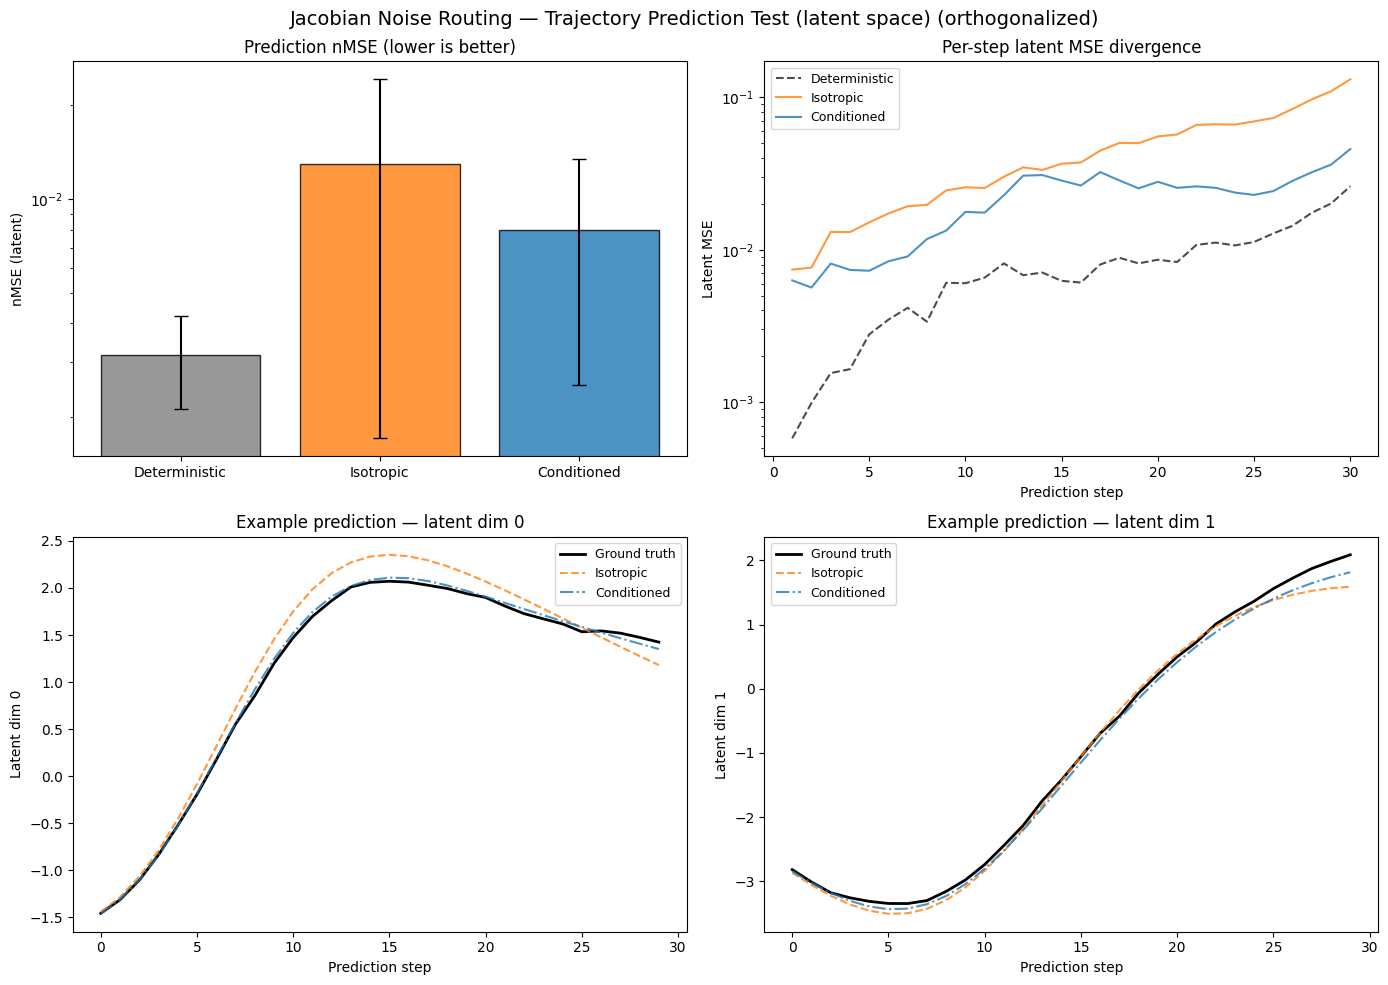

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from JacobianODE.jacobians.jacobianODE import JacobianODEint
from JacobianODE.jacobians.metrics import normalized_mse

# ── Configuration ──────────────────────────────────────────────────────
NOISE_STD = 0.05             # fixed isotropic noise scale
N_NOISE_SAMPLES = 16         # number of noise realizations to average over
LOOKAHEAD_K = None            # None → use model's prediction_steps
N_PRED_TRAJS = 3              # number of test trajectories to use
SEED = 42
ORTHOGONALIZE = True          # polar decomposition: keep rotation, discard scaling

# ── Encode test trajectories ──────────────────────────────────────────
n_target_dims = lit_model_analysis.n_target_dims
prediction_steps = lit_model_analysis.prediction_steps
traj_init_steps = 15  # standard init window

with torch.no_grad():
    traj_seq = torch.as_tensor(trajs["test_trajs"].sequence[:N_PRED_TRAJS]).float().to(device)
    z_full = lit_model_analysis.encode_trajectory(traj_seq)  # (B, T, D_full)

# Split into dynamic subspace
if n_target_dims is not None:
    mu_dyn = z_full[..., :n_target_dims]
else:
    mu_dyn = z_full

B, T, D = mu_dyn.shape
K = LOOKAHEAD_K or prediction_steps
window_len = traj_init_steps + prediction_steps

print(f"Trajectories: {B}, Latent T: {T}, D_dyn: {D}")
print(f"Init steps: {traj_init_steps}, Prediction steps: {prediction_steps}")
print(f"Lookahead K: {K}, Noise std: {NOISE_STD}, Orthogonalize: {ORTHOGONALIZE}")

# ── Compute routing matrices A_t ──────────────────────────────────────
with torch.no_grad():
    J = lit_model_analysis.compute_jacobians(mu_dyn)  # (B, T, D, D)

# Make traceless
trace_J = torch.diagonal(J, dim1=-2, dim2=-1).sum(-1)  # (B, T)
eye = torch.eye(D, device=device, dtype=mu_dyn.dtype)
J_tilde = J - (trace_J / D).unsqueeze(-1).unsqueeze(-1) * eye

# Single-step backward matrices
E = torch.linalg.matrix_exp(-J_tilde * dt)  # (B, T, D, D)

# Rolling window product
A = E.clone()
for k in range(1, K):
    t_end = T - k
    if t_end <= 0:
        break
    A[:, :t_end] = A[:, :t_end] @ E[:, k:k + t_end]

# Optionally orthogonalize via polar decomposition: A = U @ P, keep U
if ORTHOGONALIZE:
    U_svd, S_svd, Vh_svd = torch.linalg.svd(A)
    A = U_svd @ Vh_svd  # orthogonal factor (rotation/reflection only)
    print(f"Orthogonalized A — singular values discarded")
    print(f"  Original A singular value range: [{S_svd.min().item():.4f}, {S_svd.max().item():.4f}]")

# Verify volume preservation
dets = torch.linalg.det(A)
print(f"det(A) — mean: {dets.mean().item():.6f}, std: {dets.std().item():.6f} (should be ≈±1)")

# ── Run predictions with both noise types ─────────────────────────────
jacobian_odeint = JacobianODEint(lit_model_analysis.compute_jacobians, dt)

# We'll collect per-sample nMSE for each noise type
nmse_iso_all = []
nmse_cond_all = []
# Store one example for plotting
example_pred_iso = None
example_pred_cond = None
example_truth = None

# Use a single starting window per trajectory (first valid window)
z_windows = mu_dyn[:, :window_len, :]  # (B, window_len, D)
A_window = A[:, :window_len, :, :]

# Ground truth latent trajectory in the prediction region
z_true_pred = z_windows[:, traj_init_steps:, :]  # (B, pred_steps, D)

for s in range(N_NOISE_SAMPLES):
    torch.manual_seed(SEED + s)
    eps = torch.randn(B, window_len, D, device=device, dtype=mu_dyn.dtype)
    noise = NOISE_STD * eps

    # ── Isotropic: z = mu + noise ──
    z_iso = z_windows + noise

    # ── Conditioned: z = mu + A @ noise ──
    routed_noise = torch.einsum('btij,btj->bti', A_window, noise)
    z_cond = z_windows + routed_noise

    with torch.no_grad():
        # Predict with isotropic noise
        z_pred_iso = jacobian_odeint.generate_dynamics(
            z_iso,
            alpha_teacher_forcing=0,
            teacher_forcing_steps=1,
            fast_mode=True,
            scale_interp_pts=True,
            traj_init_steps=traj_init_steps,
        )
        z_pred_iso_crop = z_pred_iso[:, traj_init_steps:, :]

        # Predict with conditioned noise
        z_pred_cond = jacobian_odeint.generate_dynamics(
            z_cond,
            alpha_teacher_forcing=0,
            teacher_forcing_steps=1,
            fast_mode=True,
            scale_interp_pts=True,
            traj_init_steps=traj_init_steps,
        )
        z_pred_cond_crop = z_pred_cond[:, traj_init_steps:, :]

    # Per-trajectory nMSE in latent space
    for b in range(B):
        nmse_iso_all.append(normalized_mse(z_true_pred[b], z_pred_iso_crop[b]).item())
        nmse_cond_all.append(normalized_mse(z_true_pred[b], z_pred_cond_crop[b]).item())

    # Save first sample for plotting
    if s == 0:
        example_pred_iso = z_pred_iso_crop.detach().cpu().numpy()
        example_pred_cond = z_pred_cond_crop.detach().cpu().numpy()
        example_truth = z_true_pred.detach().cpu().numpy()

nmse_iso_all = np.array(nmse_iso_all)
nmse_cond_all = np.array(nmse_cond_all)

# ── Also compute nMSE for the deterministic (no noise) baseline ───────
with torch.no_grad():
    z_pred_det = jacobian_odeint.generate_dynamics(
        z_windows,
        alpha_teacher_forcing=0,
        teacher_forcing_steps=1,
        fast_mode=True,
        scale_interp_pts=True,
        traj_init_steps=traj_init_steps,
    )
    z_pred_det_crop = z_pred_det[:, traj_init_steps:, :]
    nmse_det = np.array([normalized_mse(z_true_pred[b], z_pred_det_crop[b]).item() for b in range(B)])

# ── Per-step MSE in latent space ──────────────────────────────────────
torch.manual_seed(SEED)
eps = torch.randn(B, window_len, D, device=device, dtype=mu_dyn.dtype)
noise = NOISE_STD * eps
with torch.no_grad():
    z_pred_iso_ex = jacobian_odeint.generate_dynamics(
        z_windows + noise, alpha_teacher_forcing=0, teacher_forcing_steps=1,
        fast_mode=True, scale_interp_pts=True, traj_init_steps=traj_init_steps)
    z_pred_cond_ex = jacobian_odeint.generate_dynamics(
        z_windows + torch.einsum('btij,btj->bti', A_window, noise),
        alpha_teacher_forcing=0, teacher_forcing_steps=1,
        fast_mode=True, scale_interp_pts=True, traj_init_steps=traj_init_steps)

    z_iso_crop = z_pred_iso_ex[:, traj_init_steps:, :]
    z_cond_crop = z_pred_cond_ex[:, traj_init_steps:, :]
    z_det_crop2 = z_pred_det_crop

    # Per-step MSE in latent space
    mse_iso_step = ((z_iso_crop - z_true_pred) ** 2).mean(dim=(0, -1)).cpu().numpy()
    mse_cond_step = ((z_cond_crop - z_true_pred) ** 2).mean(dim=(0, -1)).cpu().numpy()
    mse_det_step = ((z_det_crop2 - z_true_pred) ** 2).mean(dim=(0, -1)).cpu().numpy()

# ── Print summary ─────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"Jacobian Noise Routing — Trajectory Prediction Test")
print(f"{'='*60}")
print(f"  Noise std: {NOISE_STD}  |  K: {K}  |  Samples: {N_NOISE_SAMPLES}  |  Ortho: {ORTHOGONALIZE}")
print(f"\n{'Method':<24} {'Mean nMSE':>12} {'Median nMSE':>14} {'Std nMSE':>12}")
print(f"{'-'*62}")
print(f"  {'Deterministic (no noise)':<22} {nmse_det.mean():>12.6f} {np.median(nmse_det):>14.6f} {nmse_det.std():>12.6f}")
print(f"  {'Isotropic noise':<22} {nmse_iso_all.mean():>12.6f} {np.median(nmse_iso_all):>14.6f} {nmse_iso_all.std():>12.6f}")
print(f"  {'Conditioned noise':<22} {nmse_cond_all.mean():>12.6f} {np.median(nmse_cond_all):>14.6f} {nmse_cond_all.std():>12.6f}")
improvement = (nmse_iso_all.mean() - nmse_cond_all.mean()) / nmse_iso_all.mean() * 100
print(f"\n  Conditioned vs Isotropic: {improvement:+.1f}% change in mean nMSE")

# ── Plots ─────────────────────────────────────────────────────────────
ortho_label = " (orthogonalized)" if ORTHOGONALIZE else " (raw)"
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Jacobian Noise Routing — Trajectory Prediction Test (latent space){ortho_label}",
             fontsize=14)

# (0,0) Bar chart: mean nMSE comparison
ax = axes[0, 0]
methods = ["Deterministic", "Isotropic", "Conditioned"]
means = [nmse_det.mean(), nmse_iso_all.mean(), nmse_cond_all.mean()]
stds = [nmse_det.std(), nmse_iso_all.std(), nmse_cond_all.std()]
colors = ["tab:gray", "tab:orange", "tab:blue"]
bars = ax.bar(methods, means, yerr=stds, capsize=5, color=colors, alpha=0.8, edgecolor="black")
ax.set_ylabel("nMSE (latent)")
ax.set_title("Prediction nMSE (lower is better)")
ax.set_yscale("log")

# (0,1) Per-step error curves
ax = axes[0, 1]
steps = np.arange(1, len(mse_det_step) + 1)
ax.plot(steps, mse_det_step, "k--", label="Deterministic", alpha=0.7)
ax.plot(steps, mse_iso_step, color="tab:orange", label="Isotropic", alpha=0.8)
ax.plot(steps, mse_cond_step, color="tab:blue", label="Conditioned", alpha=0.8)
ax.set_xlabel("Prediction step")
ax.set_ylabel("Latent MSE")
ax.set_title("Per-step latent MSE divergence")
ax.legend(fontsize=9)
ax.set_yscale("log")

# (1,0) and (1,1): Example trajectory plots (first 2 latent dims of traj 0)
n_plot_dims = min(D, 2)
for dim_idx in range(n_plot_dims):
    ax = axes[1, dim_idx]
    t_plot = np.arange(example_truth.shape[1])
    ax.plot(t_plot, example_truth[0, :, dim_idx], "k-", linewidth=2, label="Ground truth")
    ax.plot(t_plot, example_pred_iso[0, :, dim_idx], color="tab:orange",
            linestyle="--", alpha=0.8, label="Isotropic")
    ax.plot(t_plot, example_pred_cond[0, :, dim_idx], color="tab:blue",
            linestyle="-.", alpha=0.8, label="Conditioned")
    ax.set_xlabel("Prediction step")
    ax.set_ylabel(f"Latent dim {dim_idx}")
    ax.set_title(f"Example prediction — latent dim {dim_idx}")
    ax.legend(fontsize=9)

if n_plot_dims < 2:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# Run Picking

Found 58 total runs in JacobianODE/Lorenz_INDall_N25_D1_NormTrue_T3__JacobianODE (group=spline_coupling__geometric_noise__sweep_lc_x_kl_dyn)
All runs (state, loop_closure_weight, tangent_entropy_weight, kl_dyn_weight):
  iba4uscv: state=finished, lc=0.0, te=0.0, kl_dyn=1e-06
  z45134nb: state=finished, lc=0.0, te=0.0, kl_dyn=1e-05
  ivu71awi: state=finished, lc=0.0, te=0.0, kl_dyn=0.0
  ychptrw8: state=finished, lc=0.0, te=0.0, kl_dyn=0.001
  gt9lih8p: state=finished, lc=0.0, te=0.0, kl_dyn=0.0001
  hgcm803f: state=finished, lc=0.0, te=0.0, kl_dyn=0.01
  u2jlrgak: state=finished, lc=1e-06, te=0.0, kl_dyn=1e-06
  g5sfhnow: state=finished, lc=1e-06, te=0.0, kl_dyn=0.0
  m91dyca7: state=finished, lc=0.0, te=0.0, kl_dyn=10.0
  xxx6rxyz: state=finished, lc=0.0, te=0.0, kl_dyn=0.1
  7pgabc68: state=finished, lc=0.0, te=0.0, kl_dyn=1.0
  awd5ydyn: state=finished, lc=1e-06, te=0.0, kl_dyn=1e-05
  f4mljfmy: state=finished, lc=1e-06, te=0.0, kl_dyn=0.01
  t1rlzjag: state=finished, lc=1e-06, te=0

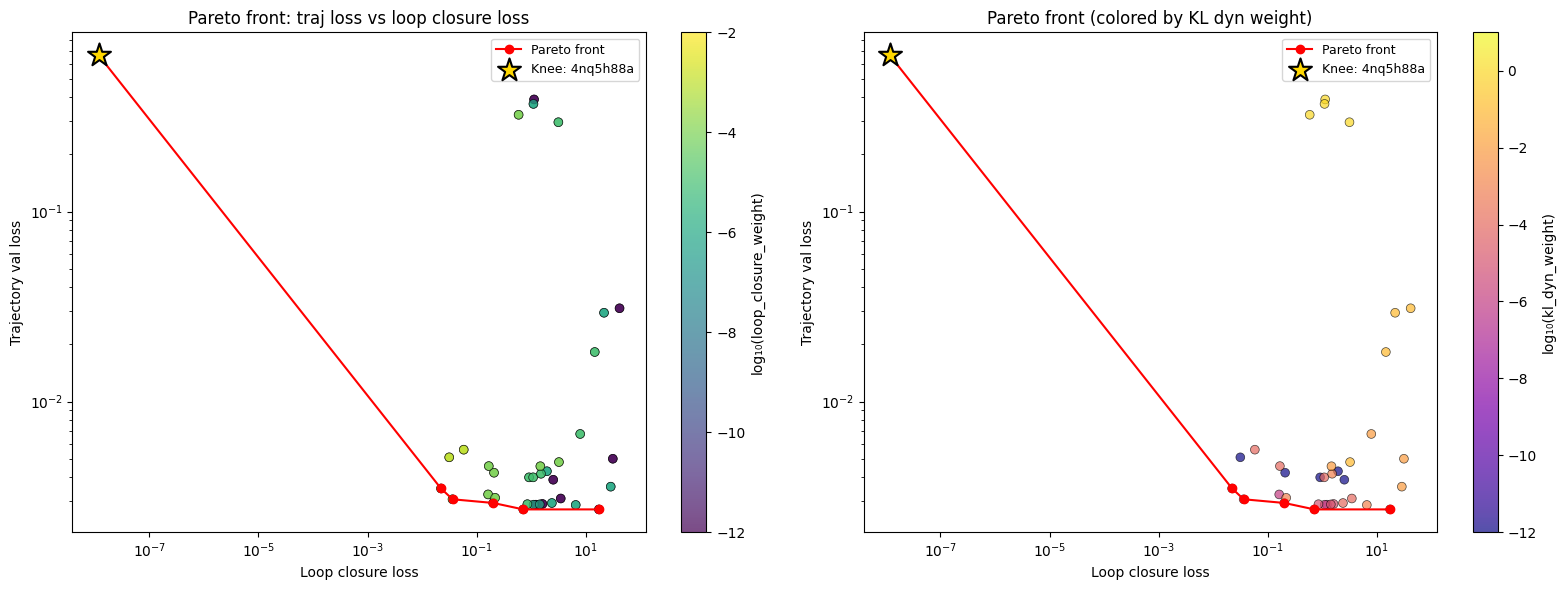


Pareto-optimal runs (11):
  m91dyca7: traj_loss=0.667798, lc_loss=0.000000, lc_weight=0.0, kl_weight=10.0
  oteo92r8: traj_loss=0.667798, lc_loss=0.000000, lc_weight=1e-06, kl_weight=10.0
  2pgk4o95: traj_loss=0.667798, lc_loss=0.000000, lc_weight=1e-05, kl_weight=10.0
  tr0pjmf8: traj_loss=0.667798, lc_loss=0.000000, lc_weight=0.001, kl_weight=10.0
  hhqc8ig4: traj_loss=0.667798, lc_loss=0.000000, lc_weight=0.01, kl_weight=10.0
  4nq5h88a: traj_loss=0.667791, lc_loss=0.000000, lc_weight=0.0001, kl_weight=10.0 ★
  511jm7ff: traj_loss=0.003488, lc_loss=0.022127, lc_weight=0.001, kl_weight=1e-06
  uwls5gud: traj_loss=0.003060, lc_loss=0.036059, lc_weight=0.001, kl_weight=1e-05
  iso3lgfz: traj_loss=0.002926, lc_loss=0.200251, lc_weight=0.0001, kl_weight=1e-05
  joede8bu: traj_loss=0.002706, lc_loss=0.714347, lc_weight=1e-05, kl_weight=1e-06
  ychptrw8: traj_loss=0.002706, lc_loss=17.332775, lc_weight=0.0, kl_weight=0.001


In [9]:
import numpy as _np
import matplotlib.pyplot as _plt
from JacobianODE.jacobians.tuning.sweep import (
    discover_sweep_runs,
    select_from_wandb_runs,
)
from JacobianODE.jacobians import load_run as _load_run

# --- Discover all finished runs in the sweep ---
discovered = discover_sweep_runs(
    WANDB_ENTITY, WANDB_PROJECT, WANDB_GROUP, verbose=True,
)

# --- Load one run to get data dimensions ---
_project_path = f"{WANDB_ENTITY}/{WANDB_PROJECT}"
_run0, _cfg0, _, _dt0, _vals0, _, _, _, _, _ = _load_run(
    _project_path, run_id=discovered.run_ids[0],
    save_dir=SAVE_DIR, generate_data=True, verbose=False,
)
from omegaconf import OmegaConf
_delay = _cfg0.data.train_test_params.delay_embedding_params
_n_delays = int(_delay.n_delays)
if _delay.observed_indices == "all":
    _n_dims = int(_vals0.shape[-1]) * _n_delays
else:
    _n_dims = len(_delay.observed_indices) * _n_delays
_n_latent = OmegaConf.select(_cfg0, "model.encoder.n_latent", default=None)
if _n_latent is None:
    _n_latent = _n_dims

# --- Fetch diagnostics for all runs (from cache / W&B history) ---
sweep_result = select_from_wandb_runs(
    run_ids=discovered.run_ids,
    project=_project_path,
    dt=_dt0,
    n_dims=_n_dims,
    lambda_values=discovered.lambdas,
    save_dir=SAVE_DIR,
    verbose=True,
    n_latent=_n_latent,
)

# --- Extract arrays ---
traj_losses = _np.array([d.trajectory_val_loss for d in sweep_result.all_diagnostics])
lc_losses = _np.array([
    d.loop_closure_loss if d.loop_closure_loss is not None else _np.nan
    for d in sweep_result.all_diagnostics
])
lc_weights = _np.array(discovered.lambdas)
kl_weights = _np.array(discovered.kl_dyn_weights)
run_ids_all = discovered.run_ids

# --- Identify Pareto-optimal runs (lower is better on both axes) ---
valid = ~_np.isnan(lc_losses)
pareto_mask = _np.zeros(len(traj_losses), dtype=bool)
for i in range(len(traj_losses)):
    if not valid[i]:
        continue
    dominated = False
    for j in range(len(traj_losses)):
        if i == j or not valid[j]:
            continue
        if traj_losses[j] <= traj_losses[i] and lc_losses[j] <= lc_losses[i]:
            if traj_losses[j] < traj_losses[i] or lc_losses[j] < lc_losses[i]:
                dominated = True
                break
    if not dominated:
        pareto_mask[i] = True

# --- Plot ---
fig, axes = _plt.subplots(1, 2, figsize=(16, 6))

# Left: colored by loop_closure_weight
ax = axes[0]
sc = ax.scatter(
    lc_losses[valid], traj_losses[valid],
    c=_np.log10(lc_weights[valid] + 1e-12), cmap="viridis",
    s=40, alpha=0.7, edgecolors="black", linewidths=0.5,
)
# Pareto front line
pareto_idx = _np.where(pareto_mask)[0]
pareto_order = pareto_idx[_np.argsort(lc_losses[pareto_idx])]

# --- Knee point detection (max curvature in log-log space) ---
# Work in log space since both axes span orders of magnitude
knee_idx = None
if len(pareto_order) >= 3:
    x_log = _np.log10(lc_losses[pareto_order])
    y_log = _np.log10(traj_losses[pareto_order])
    # Normalize to [0, 1] so curvature isn't biased by axis scale
    x_n = (x_log - x_log.min()) / (x_log.max() - x_log.min() + 1e-12)
    y_n = (y_log - y_log.min()) / (y_log.max() - y_log.min() + 1e-12)
    # Discrete curvature via cross product of consecutive edge vectors
    dx = _np.diff(x_n)
    dy = _np.diff(y_n)
    curvature = _np.abs(dx[:-1] * dy[1:] - dx[1:] * dy[:-1]) / (
        _np.sqrt(dx[:-1]**2 + dy[:-1]**2) * _np.sqrt(dx[1:]**2 + dy[1:]**2) + 1e-12
    )
    knee_local = _np.argmax(curvature) + 1
    knee_idx = pareto_order[knee_local]
    knee_run_id = run_ids_all[knee_idx]
    print(f"\n★ Knee point: {knee_run_id}")
    print(f"  traj_loss={traj_losses[knee_idx]:.6f}, lc_loss={lc_losses[knee_idx]:.6f}")
    print(f"  lc_weight={lc_weights[knee_idx]}, kl_weight={kl_weights[knee_idx]}")
elif len(pareto_order) > 0:
    knee_local = len(pareto_order) // 2
    knee_idx = pareto_order[knee_local]
    print(f"\n★ Knee point (too few for curvature, using midpoint): {run_ids_all[knee_idx]}")

# --- Plot ---
for ax_idx, (cval, cmap_name, clabel) in enumerate([
    (_np.log10(lc_weights[valid] + 1e-12), "viridis", "log₁₀(loop_closure_weight)"),
    (_np.log10(kl_weights[valid] + 1e-12), "plasma", "log₁₀(kl_dyn_weight)"),
]):
    ax = axes[ax_idx]
    sc = ax.scatter(
        lc_losses[valid], traj_losses[valid],
        c=cval, cmap=cmap_name,
        s=40, alpha=0.7, edgecolors="black", linewidths=0.5,
    )
    ax.plot(
        lc_losses[pareto_order], traj_losses[pareto_order],
        "r-o", markersize=6, linewidth=1.5, label="Pareto front", zorder=5,
    )
    if knee_idx is not None:
        ax.scatter(
            [lc_losses[knee_idx]], [traj_losses[knee_idx]],
            marker="*", s=300, c="gold", edgecolors="black",
            linewidths=1.5, zorder=10, label=f"Knee: {run_ids_all[knee_idx]}",
        )
    ax.set_xlabel("Loop closure loss")
    ax.set_ylabel("Trajectory val loss")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=9)
    cb = fig.colorbar(sc, ax=ax)
    cb.set_label(clabel)
axes[0].set_title("Pareto front: traj loss vs loop closure loss")
axes[1].set_title("Pareto front (colored by KL dyn weight)")

_plt.tight_layout()
_plt.show()

# --- Print Pareto-optimal runs ---
print(f"\nPareto-optimal runs ({pareto_mask.sum()}):")
for i in pareto_order:
    marker = " ★" if i == knee_idx else ""
    print(
        f"  {run_ids_all[i]}: traj_loss={traj_losses[i]:.6f}, "
        f"lc_loss={lc_losses[i]:.6f}, lc_weight={lc_weights[i]}, "
        f"kl_weight={kl_weights[i]}{marker}"
    )

★ Best run (geometric mean of ranks): joede8bu
  traj_loss=0.002706, lc_loss=0.714347
  lc_weight=1e-05, kl_weight=1e-06
  traj_rank=2.0, lc_rank=17.0, geo_mean=5.83

★ Best run (minimax / most balanced): uwls5gud
  traj_loss=0.003060, lc_loss=0.036059
  lc_weight=0.001, kl_weight=1e-05
  traj_rank=11.0, lc_rank=9.0, max_rank=11.0


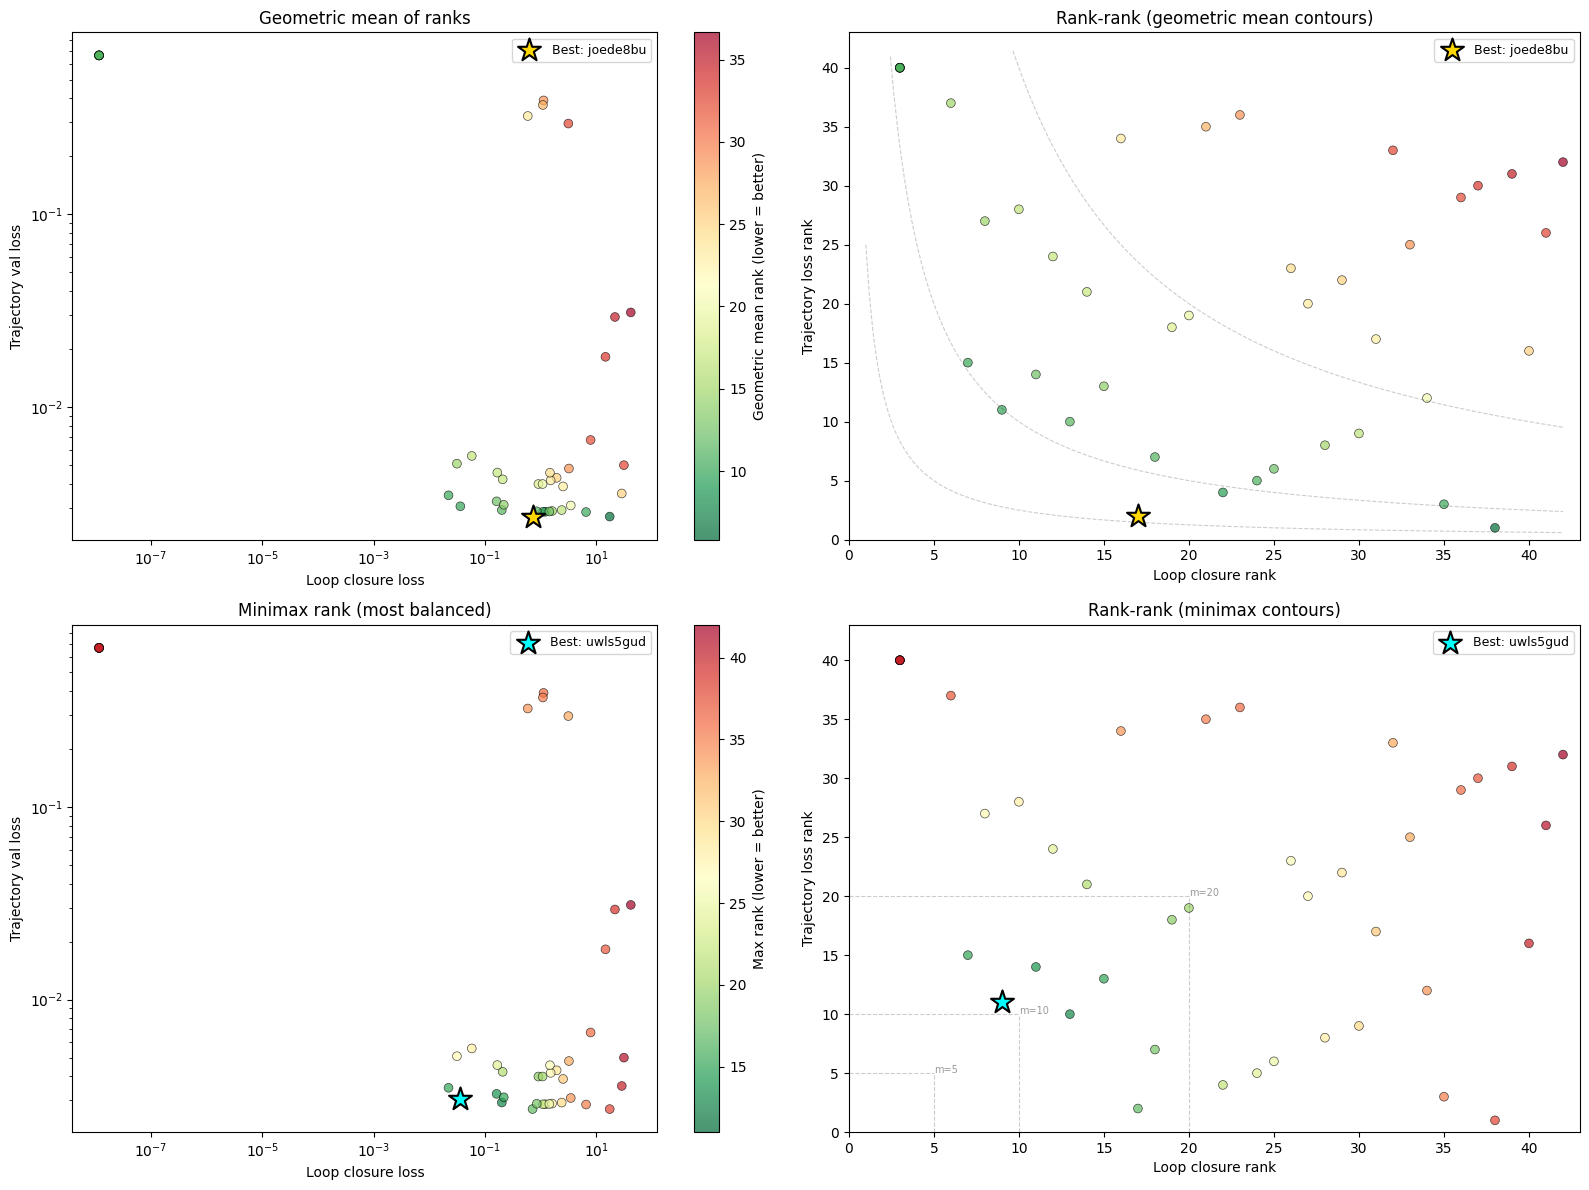


Top 10 — Geometric mean of ranks:
   1. joede8bu: traj_loss=0.002706, lc_loss=0.714347, geo=5.83, lc_weight=1e-05, kl_weight=1e-06
   2. ychptrw8: traj_loss=0.002706, lc_loss=17.332775, geo=6.16, lc_weight=0.0, kl_weight=0.001
   3. u2jlrgak: traj_loss=0.002865, lc_loss=1.102520, geo=9.38, lc_weight=1e-06, kl_weight=1e-06
   4. uwls5gud: traj_loss=0.003060, lc_loss=0.036059, geo=9.95, lc_weight=0.001, kl_weight=1e-05
   5. 511jm7ff: traj_loss=0.003488, lc_loss=0.022127, geo=10.25, lc_weight=0.001, kl_weight=1e-06
   6. jsxjnuvy: traj_loss=0.002856, lc_loss=6.518736, geo=10.25, lc_weight=1e-06, kl_weight=0.001
   7. m91dyca7: traj_loss=0.667798, lc_loss=0.000000, geo=10.95, lc_weight=0.0, kl_weight=10.0
   8. 2pgk4o95: traj_loss=0.667798, lc_loss=0.000000, geo=10.95, lc_weight=1e-05, kl_weight=10.0
   9. tr0pjmf8: traj_loss=0.667798, lc_loss=0.000000, geo=10.95, lc_weight=0.001, kl_weight=10.0
  10. hhqc8ig4: traj_loss=0.667798, lc_loss=0.000000, geo=10.95, lc_weight=0.01, kl_weight=10

In [10]:
import numpy as _np
import matplotlib.pyplot as _plt
from scipy.stats import rankdata

# --- Geometric mean of ranks (lower is better for both metrics) ---
# Only rank valid runs (non-NaN loop closure)
valid_idx = _np.where(valid)[0]
traj_valid = traj_losses[valid_idx]
lc_valid = lc_losses[valid_idx]

# Rank each metric (1 = best = lowest value)
traj_ranks = rankdata(traj_valid, method="average")
lc_ranks = rankdata(lc_valid, method="average")

# Geometric mean of ranks
geo_mean_ranks = _np.sqrt(traj_ranks * lc_ranks)

# Best run = lowest geometric mean rank
best_local = _np.argmin(geo_mean_ranks)
best_global = valid_idx[best_local]
best_run_id = run_ids_all[best_global]

# Minimax: best worst-case rank (most balanced run)
max_ranks = _np.maximum(traj_ranks, lc_ranks)
minimax_local = _np.argmin(max_ranks)
minimax_global = valid_idx[minimax_local]
minimax_run_id = run_ids_all[minimax_global]

print(f"★ Best run (geometric mean of ranks): {best_run_id}")
print(f"  traj_loss={traj_losses[best_global]:.6f}, lc_loss={lc_losses[best_global]:.6f}")
print(f"  lc_weight={lc_weights[best_global]}, kl_weight={kl_weights[best_global]}")
print(f"  traj_rank={traj_ranks[best_local]:.1f}, lc_rank={lc_ranks[best_local]:.1f}, "
      f"geo_mean={geo_mean_ranks[best_local]:.2f}")

print(f"\n★ Best run (minimax / most balanced): {minimax_run_id}")
print(f"  traj_loss={traj_losses[minimax_global]:.6f}, lc_loss={lc_losses[minimax_global]:.6f}")
print(f"  lc_weight={lc_weights[minimax_global]}, kl_weight={kl_weights[minimax_global]}")
print(f"  traj_rank={traj_ranks[minimax_local]:.1f}, lc_rank={lc_ranks[minimax_local]:.1f}, "
      f"max_rank={max_ranks[minimax_local]:.1f}")

if best_run_id == minimax_run_id:
    print("\n  (Both criteria agree!)")

# --- Plot: 2x2 grid ---
_fig, _axes = _plt.subplots(2, 2, figsize=(16, 12))

# (0,0) Geometric mean — loss space
_ax = _axes[0, 0]
_sc = _ax.scatter(
    lc_valid, traj_valid,
    c=geo_mean_ranks, cmap="RdYlGn_r",
    s=40, alpha=0.7, edgecolors="black", linewidths=0.5,
)
_ax.scatter(
    [lc_losses[best_global]], [traj_losses[best_global]],
    marker="*", s=300, c="gold", edgecolors="black",
    linewidths=1.5, zorder=10, label=f"Best: {best_run_id}",
)
_ax.set_xlabel("Loop closure loss")
_ax.set_ylabel("Trajectory val loss")
_ax.set_title("Geometric mean of ranks")
_ax.set_xscale("log")
_ax.set_yscale("log")
_ax.legend(fontsize=9)
_cb = _fig.colorbar(_sc, ax=_ax)
_cb.set_label("Geometric mean rank (lower = better)")

# (0,1) Geometric mean — rank space
_ax = _axes[0, 1]
_ax.scatter(
    lc_ranks, traj_ranks,
    c=geo_mean_ranks, cmap="RdYlGn_r",
    s=40, alpha=0.7, edgecolors="black", linewidths=0.5,
)
_ax.scatter(
    [lc_ranks[best_local]], [traj_ranks[best_local]],
    marker="*", s=300, c="gold", edgecolors="black",
    linewidths=1.5, zorder=10, label=f"Best: {best_run_id}",
)
_N = len(traj_valid)
_r = _np.linspace(1, _N, 200)
for _level in [5, 10, 20]:
    _curve = _level**2 / _r
    _m = _curve <= _N
    if _m.any():
        _ax.plot(_r[_m], _curve[_m], "k--", alpha=0.2, linewidth=0.8)
_ax.set_xlabel("Loop closure rank")
_ax.set_ylabel("Trajectory loss rank")
_ax.set_title("Rank-rank (geometric mean contours)")
_ax.set_xlim(0, _N + 1)
_ax.set_ylim(0, _N + 1)
_ax.legend(fontsize=9)

# (1,0) Minimax — loss space
_ax = _axes[1, 0]
_sc = _ax.scatter(
    lc_valid, traj_valid,
    c=max_ranks, cmap="RdYlGn_r",
    s=40, alpha=0.7, edgecolors="black", linewidths=0.5,
)
_ax.scatter(
    [lc_losses[minimax_global]], [traj_losses[minimax_global]],
    marker="*", s=300, c="cyan", edgecolors="black",
    linewidths=1.5, zorder=10, label=f"Best: {minimax_run_id}",
)
_ax.set_xlabel("Loop closure loss")
_ax.set_ylabel("Trajectory val loss")
_ax.set_title("Minimax rank (most balanced)")
_ax.set_xscale("log")
_ax.set_yscale("log")
_ax.legend(fontsize=9)
_cb = _fig.colorbar(_sc, ax=_ax)
_cb.set_label("Max rank (lower = better)")

# (1,1) Minimax — rank space
_ax = _axes[1, 1]
_ax.scatter(
    lc_ranks, traj_ranks,
    c=max_ranks, cmap="RdYlGn_r",
    s=40, alpha=0.7, edgecolors="black", linewidths=0.5,
)
_ax.scatter(
    [lc_ranks[minimax_local]], [traj_ranks[minimax_local]],
    marker="*", s=300, c="cyan", edgecolors="black",
    linewidths=1.5, zorder=10, label=f"Best: {minimax_run_id}",
)
for _level in [5, 10, 20]:
    if _level <= _N:
        _ax.plot([_level, _level], [0, _level], "k--", alpha=0.2, linewidth=0.8)
        _ax.plot([0, _level], [_level, _level], "k--", alpha=0.2, linewidth=0.8)
        _ax.annotate(f"m={_level}", xy=(_level, _level),
                     fontsize=7, alpha=0.4, ha="left")
_ax.set_xlabel("Loop closure rank")
_ax.set_ylabel("Trajectory loss rank")
_ax.set_title("Rank-rank (minimax contours)")
_ax.set_xlim(0, _N + 1)
_ax.set_ylim(0, _N + 1)
_ax.legend(fontsize=9)

_plt.tight_layout()
_plt.show()

# --- Top 10 runs by each criterion ---
_geo_order = _np.argsort(geo_mean_ranks)[:10]
_mm_order = _np.argsort(max_ranks)[:10]
print(f"\nTop 10 — Geometric mean of ranks:")
for _rank, _loc in enumerate(_geo_order, 1):
    _g = valid_idx[_loc]
    print(
        f"  {_rank:2d}. {run_ids_all[_g]}: traj_loss={traj_losses[_g]:.6f}, "
        f"lc_loss={lc_losses[_g]:.6f}, geo={geo_mean_ranks[_loc]:.2f}, "
        f"lc_weight={lc_weights[_g]}, kl_weight={kl_weights[_g]}"
    )
print(f"\nTop 10 — Minimax rank (most balanced):")
for _rank, _loc in enumerate(_mm_order, 1):
    _g = valid_idx[_loc]
    print(
        f"  {_rank:2d}. {run_ids_all[_g]}: traj_loss={traj_losses[_g]:.6f}, "
        f"lc_loss={lc_losses[_g]:.6f}, max_rank={max_ranks[_loc]:.1f}, "
        f"lc_weight={lc_weights[_g]}, kl_weight={kl_weights[_g]}"
    )

Log-normalized scores: s = (log x - log x_min) / (log x_max - log x_min)

★ Best (geometric mean of log-scores): ychptrw8
  traj_loss=0.002706, lc_loss=17.332775
  s_traj=0.0000, s_lc=0.9604, geo=0.0000
  lc_weight=0.0, kl_weight=0.001

★ Best (minimax of log-scores, most balanced): 511jm7ff
  traj_loss=0.003488, lc_loss=0.022127
  s_traj=0.0461, s_lc=0.6572, max_s=0.6572
  lc_weight=0.001, kl_weight=1e-06


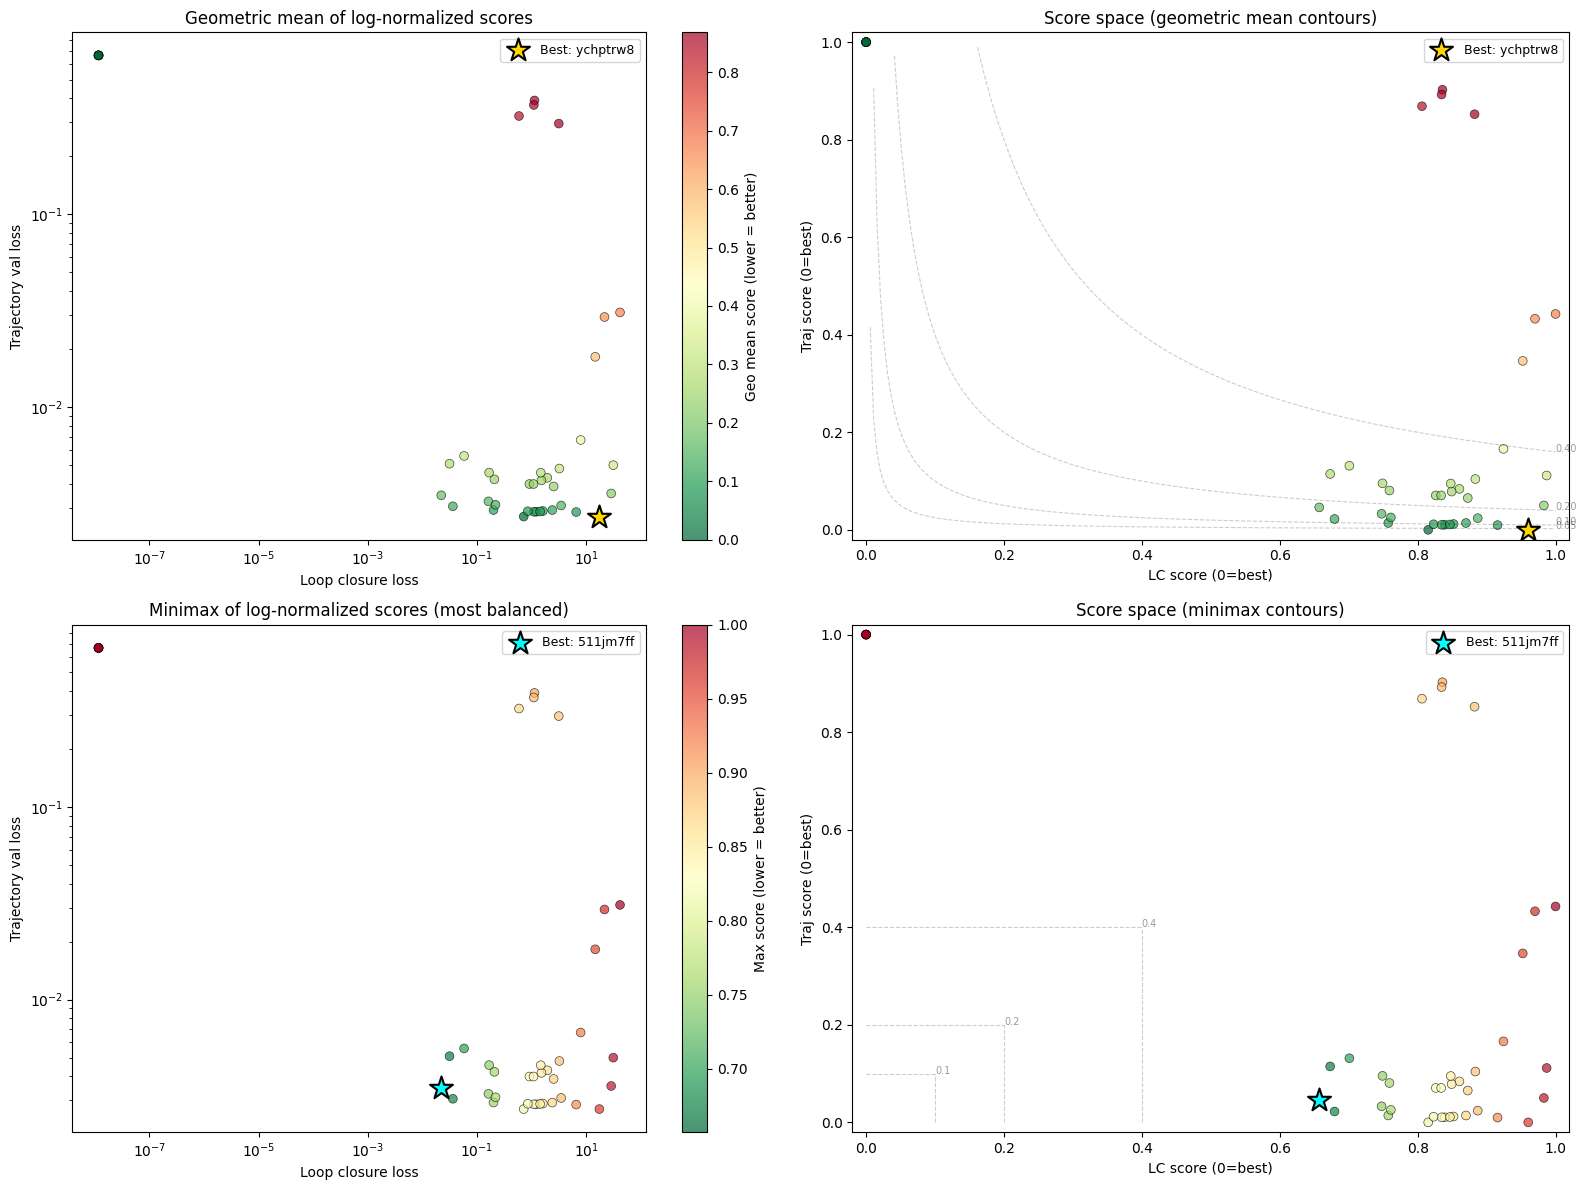


Top 10 — Geometric mean of log-scores:
   1. ychptrw8: traj_loss=0.002706, lc_loss=17.332775, geo=0.0000, lc_weight=0.0, kl_weight=0.001
   2. m91dyca7: traj_loss=0.667798, lc_loss=0.000000, geo=0.0000, lc_weight=0.0, kl_weight=10.0
   3. 2pgk4o95: traj_loss=0.667798, lc_loss=0.000000, geo=0.0000, lc_weight=1e-05, kl_weight=10.0
   4. oteo92r8: traj_loss=0.667798, lc_loss=0.000000, geo=0.0000, lc_weight=1e-06, kl_weight=10.0
   5. tr0pjmf8: traj_loss=0.667798, lc_loss=0.000000, geo=0.0000, lc_weight=0.001, kl_weight=10.0
   6. hhqc8ig4: traj_loss=0.667798, lc_loss=0.000000, geo=0.0000, lc_weight=0.01, kl_weight=10.0
   7. joede8bu: traj_loss=0.002706, lc_loss=0.714347, geo=0.0017, lc_weight=1e-05, kl_weight=1e-06
   8. 4nq5h88a: traj_loss=0.667791, lc_loss=0.000000, geo=0.0045, lc_weight=0.0001, kl_weight=10.0
   9. u2jlrgak: traj_loss=0.002865, lc_loss=1.102520, geo=0.0931, lc_weight=1e-06, kl_weight=1e-06
  10. iba4uscv: traj_loss=0.002866, lc_loss=1.212495, geo=0.0935, lc_weight=0.

In [11]:
import numpy as _np
import matplotlib.pyplot as _plt

# --- Log-normalized scores: s_i = (log x_i - log x_min) / (log x_max - log x_min) ---
# s ∈ [0, 1], 0 = best, 1 = worst. Respects relative magnitudes.
_valid_idx = _np.where(valid)[0]
_traj_v = traj_losses[_valid_idx]
_lc_v = lc_losses[_valid_idx]

_log_traj = _np.log10(_traj_v)
_log_lc = _np.log10(_lc_v)

_s_traj = (_log_traj - _log_traj.min()) / (_log_traj.max() - _log_traj.min() + 1e-12)
_s_lc = (_log_lc - _log_lc.min()) / (_log_lc.max() - _log_lc.min() + 1e-12)

# Geometric mean of log-normalized scores
_geo_scores = _np.sqrt(_s_traj * _s_lc)
_geo_best_loc = _np.argmin(_geo_scores)
_geo_best_glob = _valid_idx[_geo_best_loc]

# Minimax of log-normalized scores (most balanced)
_mm_scores = _np.maximum(_s_traj, _s_lc)
_mm_best_loc = _np.argmin(_mm_scores)
_mm_best_glob = _valid_idx[_mm_best_loc]

print("Log-normalized scores: s = (log x - log x_min) / (log x_max - log x_min)")
print(f"\n★ Best (geometric mean of log-scores): {run_ids_all[_geo_best_glob]}")
print(f"  traj_loss={traj_losses[_geo_best_glob]:.6f}, lc_loss={lc_losses[_geo_best_glob]:.6f}")
print(f"  s_traj={_s_traj[_geo_best_loc]:.4f}, s_lc={_s_lc[_geo_best_loc]:.4f}, "
      f"geo={_geo_scores[_geo_best_loc]:.4f}")
print(f"  lc_weight={lc_weights[_geo_best_glob]}, kl_weight={kl_weights[_geo_best_glob]}")

print(f"\n★ Best (minimax of log-scores, most balanced): {run_ids_all[_mm_best_glob]}")
print(f"  traj_loss={traj_losses[_mm_best_glob]:.6f}, lc_loss={lc_losses[_mm_best_glob]:.6f}")
print(f"  s_traj={_s_traj[_mm_best_loc]:.4f}, s_lc={_s_lc[_mm_best_loc]:.4f}, "
      f"max_s={_mm_scores[_mm_best_loc]:.4f}")
print(f"  lc_weight={lc_weights[_mm_best_glob]}, kl_weight={kl_weights[_mm_best_glob]}")

if run_ids_all[_geo_best_glob] == run_ids_all[_mm_best_glob]:
    print("\n  (Both criteria agree!)")

# --- Plot: 2x2 ---
_fig, _axes = _plt.subplots(2, 2, figsize=(16, 12))

# (0,0) Geometric mean — loss space
_ax = _axes[0, 0]
_sc = _ax.scatter(
    _lc_v, _traj_v, c=_geo_scores, cmap="RdYlGn_r",
    s=40, alpha=0.7, edgecolors="black", linewidths=0.5,
)
_ax.scatter(
    [lc_losses[_geo_best_glob]], [traj_losses[_geo_best_glob]],
    marker="*", s=300, c="gold", edgecolors="black",
    linewidths=1.5, zorder=10, label=f"Best: {run_ids_all[_geo_best_glob]}",
)
_ax.set_xlabel("Loop closure loss")
_ax.set_ylabel("Trajectory val loss")
_ax.set_title("Geometric mean of log-normalized scores")
_ax.set_xscale("log")
_ax.set_yscale("log")
_ax.legend(fontsize=9)
_cb = _fig.colorbar(_sc, ax=_ax)
_cb.set_label("Geo mean score (lower = better)")

# (0,1) Geometric mean — score space
_ax = _axes[0, 1]
_sc = _ax.scatter(
    _s_lc, _s_traj, c=_geo_scores, cmap="RdYlGn_r",
    s=40, alpha=0.7, edgecolors="black", linewidths=0.5,
)
_ax.scatter(
    [_s_lc[_geo_best_loc]], [_s_traj[_geo_best_loc]],
    marker="*", s=300, c="gold", edgecolors="black",
    linewidths=1.5, zorder=10, label=f"Best: {run_ids_all[_geo_best_glob]}",
)
_s = _np.linspace(0.001, 1, 200)
for _level in [0.05, 0.1, 0.2, 0.4]:
    _curve = _level**2 / _s
    _m = _curve <= 1
    if _m.any():
        _ax.plot(_s[_m], _curve[_m], "k--", alpha=0.2, linewidth=0.8)
        _ax.annotate(f"{_level:.2f}", xy=(_s[_m][-1], _curve[_m][-1]),
                     fontsize=7, alpha=0.4, ha="left")
_ax.set_xlabel("LC score (0=best)")
_ax.set_ylabel("Traj score (0=best)")
_ax.set_title("Score space (geometric mean contours)")
_ax.set_xlim(-0.02, 1.02)
_ax.set_ylim(-0.02, 1.02)
_ax.legend(fontsize=9)

# (1,0) Minimax — loss space
_ax = _axes[1, 0]
_sc = _ax.scatter(
    _lc_v, _traj_v, c=_mm_scores, cmap="RdYlGn_r",
    s=40, alpha=0.7, edgecolors="black", linewidths=0.5,
)
_ax.scatter(
    [lc_losses[_mm_best_glob]], [traj_losses[_mm_best_glob]],
    marker="*", s=300, c="cyan", edgecolors="black",
    linewidths=1.5, zorder=10, label=f"Best: {run_ids_all[_mm_best_glob]}",
)
_ax.set_xlabel("Loop closure loss")
_ax.set_ylabel("Trajectory val loss")
_ax.set_title("Minimax of log-normalized scores (most balanced)")
_ax.set_xscale("log")
_ax.set_yscale("log")
_ax.legend(fontsize=9)
_cb = _fig.colorbar(_sc, ax=_ax)
_cb.set_label("Max score (lower = better)")

# (1,1) Minimax — score space
_ax = _axes[1, 1]
_sc = _ax.scatter(
    _s_lc, _s_traj, c=_mm_scores, cmap="RdYlGn_r",
    s=40, alpha=0.7, edgecolors="black", linewidths=0.5,
)
_ax.scatter(
    [_s_lc[_mm_best_loc]], [_s_traj[_mm_best_loc]],
    marker="*", s=300, c="cyan", edgecolors="black",
    linewidths=1.5, zorder=10, label=f"Best: {run_ids_all[_mm_best_glob]}",
)
for _level in [0.1, 0.2, 0.4]:
    _ax.plot([_level, _level], [0, _level], "k--", alpha=0.2, linewidth=0.8)
    _ax.plot([0, _level], [_level, _level], "k--", alpha=0.2, linewidth=0.8)
    _ax.annotate(f"{_level:.1f}", xy=(_level, _level),
                 fontsize=7, alpha=0.4, ha="left")
_ax.set_xlabel("LC score (0=best)")
_ax.set_ylabel("Traj score (0=best)")
_ax.set_title("Score space (minimax contours)")
_ax.set_xlim(-0.02, 1.02)
_ax.set_ylim(-0.02, 1.02)
_ax.legend(fontsize=9)

_plt.tight_layout()
_plt.show()

# --- Top 10 by each criterion ---
_geo_order = _np.argsort(_geo_scores)[:10]
_mm_order = _np.argsort(_mm_scores)[:10]
print(f"\nTop 10 — Geometric mean of log-scores:")
for _rank, _loc in enumerate(_geo_order, 1):
    _g = _valid_idx[_loc]
    print(
        f"  {_rank:2d}. {run_ids_all[_g]}: traj_loss={traj_losses[_g]:.6f}, "
        f"lc_loss={lc_losses[_g]:.6f}, geo={_geo_scores[_loc]:.4f}, "
        f"lc_weight={lc_weights[_g]}, kl_weight={kl_weights[_g]}"
    )
print(f"\nTop 10 — Minimax of log-scores (most balanced):")
for _rank, _loc in enumerate(_mm_order, 1):
    _g = _valid_idx[_loc]
    print(
        f"  {_rank:2d}. {run_ids_all[_g]}: traj_loss={traj_losses[_g]:.6f}, "
        f"lc_loss={lc_losses[_g]:.6f}, max_s={_mm_scores[_loc]:.4f}, "
        f"lc_weight={lc_weights[_g]}, kl_weight={kl_weights[_g]}"
    )